# Brain-as-LLM Local Linearization Experiment

**Goal:** test whether human intracranial neural population dynamics can be treated, locally, like hidden-state dynamics in an LLM:

$$\hat{x}_{t+\Delta} = A\,x_t + b + \hat{w}_t$$

| LLM | Brain |
|---|---|
| hidden state $h[l,t]$ | population state $x[l,t]$ |
| layer $l$ | anatomical module (temporal cortex → entorhinal → hippocampus) |
| hidden-state dimension | electrode **channel** (never "neuron") |
| token index | 20-ms time bin |

**Story:** locally linearizable → finite temporal prediction horizon → degradation under state shift (placebo → scopolamine OOD).

Full specification: [ANALYSIS_SPEC.md](ANALYSIS_SPEC.md)

**Guardrails (from spec):**
- Fit dynamics **within patient** only; aggregate statistics across patients (patient = inferential unit).
- Split by **whole trials**, never individual time points; all preprocessing/hyperparameters from training data only.
- Residual model $\hat{w}_t = g(x_t)$ trained on **training residuals** — never add back test residuals.
- OOD evaluation uses the **frozen** model (same $A$, $b$, $g$, normalization).
- Report negative results honestly (spec §28).

## Dataset: Basu et al., *Nature BME* 2023 (closed-loop cognitive control)

**Paper:** "Closed-loop enhancement and neural decoding of cognitive control in humans" (doi:10.1038/s41551-021-00804-y) — [StimPaper.pdf](StimPaper.pdf).

Actual dataset properties (these override the spec's placeholder assumptions):

| Spec assumption | Actual dataset |
|---|---|
| Memory encoding task | **MSIT** conflict task, trials aligned to image onset |
| Placebo vs scopolamine | **Stimulation state**: NS1 (no-stim blocks) vs NS2 (non-stim trials in stim blocks) vs stimulated trials (130 Hz internal-capsule/striatal stim, 600 ms at image onset, 2–4 mA) |
| 1000 Hz native | Recorded 2 kHz → **decimated to 1000 Hz**, bipolar re-referenced, 60 Hz + harmonics removed, IED channels rejected |
| Temporal ctx → entorhinal → hippocampus | 16 regions incl. **PFC subdivisions, cingulate, OFC, temporal, insula, amygdala, hippocampus, NAcc, caudate** — layer hierarchy to be redefined on actual coverage |
| −500..+1500 ms epoch | Paper analyzes 0.1–1.4 s post-image (decision period); baseline −0.5..0 s. Trials cut with 2 s buffers |
| Bands 2–4…32–64 Hz | Paper bands: 4–8, 8–15, 15–30, 30–55, 65–110, 135–200 Hz (Morlet, 10 ms steps; high gamma split around the 130 Hz stim frequency) |

**OOD design (adapted):** train on **NS1** trials → test-ID: held-out NS1 → test-OOD: **NS2** (behavioral/physiological state shift without stim artifact). Stimulated trials are a stronger shift but artifact-contaminated — treat separately and exclude the 600-ms stim window or use post-stim segments.

**Files:**
- `Behavior_Stim_Subjects.mat` — 3224 trials, 9 subjects (P8–P15, P17): `subject, blockNum, trialNum, interference` (conflict 0/1), `responseTimes, responseCorrect, StimAny` (0/1), `trialStim`/`blockStim` (site labels: None, L/R DS, L/R VS, L Mid, CL variants).
- `BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat` — FieldTrip-format bipolar LFP epochs aligned to image onset, patient P12, stim session 1 (MATLAB v7.3/HDF5, ~2.7 GB; per-patient files expected).


## 0. Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths (DATA_DIR to be pointed at the provided data folder) ----
HERE = Path.cwd() if (Path.cwd() / "ANALYSIS_SPEC.md").exists() else Path("NeuroAnalysis")
DATA_DIR = HERE / "data"          # <- point to the provided data folder
RESULTS_DIR = HERE / "results"
PRED_DIR = HERE / "predictions"
FIG_DIR = HERE / "figures"
for d in (RESULTS_DIR, PRED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Signal parameters (spec §2, §4, §5) ----
FS = 1000                          # native sampling rate (Hz)
EPOCH_MS = (-500, 1500)            # baseline: -500..0, encoding: 0..1500
BANDS = {
    "slow_theta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 16),
    "beta": (16, 32),
    "gamma": (32, 64),
}
PRIMARY_BAND = "theta"
TOKEN_STRIDE_MS = 20               # brain "token" spacing
CAUSAL_WINDOW_MS = 40              # x(t) = mean power over [t-40ms, t] (no future leakage)

# ---- Horizons (spec §6) ----
PRIMARY_HORIZON_MS = 20
HORIZONS_MS = [10, 20, 50, 100, 200]

# ---- Splits (spec §8): by whole trials ----
SPLIT_FRACS = (0.6, 0.2, 0.2)      # train / val / test
RANDOM_SEED = 0

# ---- Anatomical layers (spec §3) ----
LAYERS = ["temporal_cortex", "entorhinal", "hippocampus"]

# ---- Figure colors (spec §23): identical across all panels ----
COLOR_TRUE = "black"
COLOR_LINEAR = "#1f4ea1"          # blue: A x_t
COLOR_RESIDUAL = "#c1272d"        # red:  A x_t + w_hat
COLOR_ID = "#7f9fbf"              # muted: placebo / ID
COLOR_OOD = "#bf8f7f"             # muted: scopolamine / OOD

rng = np.random.default_rng(RANDOM_SEED)
print(f"DATA_DIR = {DATA_DIR.resolve()}  (exists: {DATA_DIR.exists()})")

DATA_DIR = /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/data  (exists: False)


## 1. Load & validate data (STEP 1)

Load electrode localization + trial metadata. Validate:
- patients, sessions, trial counts per condition (placebo / scopolamine; FR / AR)
- electrode counts per region per patient (simultaneous coverage map)
- epoch alignment (-500..+1500 ms @ 1000 Hz)

*Awaiting data folder — loader will be implemented against the actual file format.*

In [2]:
import re

import h5py
import scipy.io as sio

# ---------- Behavior (all subjects) ----------
beh_raw = sio.loadmat(HERE / "Behavior_Stim_Subjects.mat", squeeze_me=True)
trial_metadata = pd.DataFrame(
    {k: beh_raw[k] for k in
     ["subject", "blockNum", "trialNum", "interference", "responseTimes",
      "responseCorrect", "StimAny", "trialStim", "blockStim"]}
)
for col in ("subject", "trialStim", "blockStim"):
    trial_metadata[col] = trial_metadata[col].astype(str)

# Trial taxonomy for the OOD design (paper's NS1/NS2 definitions):
#   NS1 = trials in blocks with no stimulation at all      -> train + ID test
#   NS2 = non-stimulated trials inside stimulation blocks  -> OOD test
#   STIM = stimulated trials (130 Hz artifact)             -> handled separately
def classify_trial(row):
    if row["blockStim"] in ("None", "NoneCL"):
        return "NS1"
    if row["trialStim"] == "None":
        return "NS2"
    return "STIM"

trial_metadata["condition"] = trial_metadata.apply(classify_trial, axis=1)
print("trials per subject x condition:")
print(trial_metadata.groupby(["subject", "condition"]).size().unstack(fill_value=0))


# ---------- Neural data loader (schema of BIPOLFieldTripFormat_* files) ----------
# Root variables (MATLAB v7.3 / HDF5):
#   ft_data3                 FieldTrip struct: fsample=1000, label (151 ch),
#                            trial = 127 x (6000 samples x 151 ch), time = -2..4 s
#   TrialDet (36 x n_trials) per-trial metadata; headers in TrialDetHeaders
#                            (incl. Conflict, Stimulation, Correct, ResponseTime)
#   ChannelPairNamesBank1/2  bipolar pair names (99 + 52 = 151)
#   ParcellationValues       (8 x 151) per channel: parc4-6 look like MNI x/y/z,
#                            parc7 a parcel label, parc0-3 tissue probabilities
#   ch_ictal                 char matrix of PAIR NAMES with interictal discharges -> exclude
#   stim                     session-level stim flag

def _rs(f, ref_or_ds):
    """Read a MATLAB string stored as uint16 codes (possibly via object ref)."""
    ds = f[ref_or_ds] if isinstance(ref_or_ds, h5py.Reference) else ref_or_ds
    return "".join(chr(int(c)) for c in np.array(ds).ravel())


def _read_string_list(f, ds):
    return [_rs(f, r) for r in np.array(ds).ravel()]


def _read_char_matrix(arr):
    """(len x n) uint16 char matrix -> list of n strings."""
    return ["".join(chr(c) for c in arr[:, i] if c) for i in range(arr.shape[1])]


def load_session(path):
    """Load one BIPOLFieldTripFormat session file.

    Returns dict:
        data      (n_trials, n_channels, n_samples) float32, image onset at t=0
        time      (n_samples,) seconds
        fs        sampling rate
        trials    DataFrame from TrialDet (one row per FT trial)
        channels  DataFrame [pair_name, bank, ictal flag, parc columns]
        ictal     list of pair NAMES flagged with interictal discharges
    """
    f = h5py.File(path, "r")
    ft = f["ft_data3"]
    fs = float(np.array(ft["fsample"]).squeeze())

    trial_refs = np.array(ft["trial"]).ravel()
    trials_raw = [np.array(f[r], dtype=np.float32) for r in trial_refs]
    # HDF5 layout: (n_samples, n_channels) -> transpose
    n_ch = len(np.array(ft["label"]).ravel())
    trials_raw = [t.T if t.shape[1] == n_ch else t for t in trials_raw]
    min_len = min(t.shape[1] for t in trials_raw)
    data = np.stack([t[:, :min_len] for t in trials_raw])
    time = np.array(f[np.array(ft["time"]).ravel()[0]]).ravel()[:min_len]

    # Per-trial metadata
    tdh = _read_string_list(f, f["TrialDetHeaders"])
    trials = pd.DataFrame(np.array(f["TrialDet"]).T, columns=tdh)

    # Channel names: bank1 + bank2 bipolar pair names
    names = (_read_char_matrix(np.array(f["ChannelPairNamesBank1"]))
             + _read_char_matrix(np.array(f["ChannelPairNamesBank2"])))
    banks = [1] * np.array(f["ChannelPairNamesBank1"]).shape[1] \
          + [2] * np.array(f["ChannelPairNamesBank2"]).shape[1]
    channels = pd.DataFrame({"pair_name": names, "bank": banks})
    parc = np.array(f["ParcellationValues"])          # (8, n_ch)
    for i in range(parc.shape[0]):
        channels[f"parc{i}"] = parc[i, :len(channels)]

    ictal = _read_char_matrix(np.array(f["ch_ictal"]))   # pair names, e.g. 'LAF10 LAF11'
    channels["ictal"] = channels["pair_name"].isin(ictal)
    stim_flag = float(np.array(f["stim"]).squeeze())
    f.close()

    assert data.shape[1] == len(channels), (data.shape, len(channels))
    return {"data": data, "time": time, "fs": fs, "trials": trials,
            "channels": channels, "ictal": ictal, "stim_flag": stim_flag}


NEURAL_FILES = sorted(HERE.glob("BIPOLFieldTripFormat_AlignedToImagePresent_*.mat"))
print("\nneural files found:")
for p in NEURAL_FILES:
    m = re.search(r"_(P\d+)_(\w+)\.mat$", p.name)
    print(f"  {p.name}  ->  patient={m.group(1)}  session={m.group(2)}  ({p.stat().st_size/1e9:.2f} GB)")


trials per subject x condition:
condition  NS1  NS2  STIM
subject                  
P10        128   96    96
P11        128   61   194
P12        159  110   114
P13        191  124   125
P14        185  192     0
P15        128  127     0
P17        126  219     0
P8         110  114   119
P9         124  128   126

neural files found:
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim1.mat  ->  patient=P12  session=NoStim1  (1.14 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat  ->  patient=P12  session=NoStim2  (0.89 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat  ->  patient=P12  session=Stim1  (0.16 GB)


In [3]:
# --- Validate the loader on the first complete session file (P12 NoStim2) ---
sess = load_session(HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat")

print(f"fs             : {sess['fs']}")
print(f"data shape     : {sess['data'].shape}  (trials, channels, samples)")
print(f"time axis      : {sess['time'][0]:.3f} .. {sess['time'][-1]:.3f} s, n={len(sess['time'])}")
print(f"n channel pairs: {len(sess['channels'])}  ({sess['channels']['ictal'].sum()} flagged ictal -> excluded)")
print(f"stim flag      : {sess['stim_flag']}")

# electrode groups by lead prefix (e.g. LAF = left anterior frontal lead)
sess["channels"]["lead"] = sess["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")
print("\nchannel pairs per lead (clean/total):")
grp = sess["channels"].groupby("lead").agg(total=("pair_name", "size"), clean=("ictal", lambda s: (~s).sum()))
print(grp.T.to_string())

display(sess["channels"].head(8))

# TrialDet sanity vs behavior table
td = sess["trials"]
print(f"\nTrialDet shape: {td.shape}")
for c in ["Conflict", "Stimulation", "Correct"]:
    print(f"  {c}: {td[c].value_counts().to_dict()}")
p12 = trial_metadata[trial_metadata.subject == "P12"]
print(f"\nBehavior file P12: NS1={len(p12[p12.condition=='NS1'])}, NS2={len(p12[p12.condition=='NS2'])}, "
      f"STIM={len(p12[p12.condition=='STIM'])}  |  this session (NoStim2): {len(td)} trials, all Stimulation=0")


fs             : 1000.0
data shape     : (127, 151, 6000)  (trials, channels, samples)
time axis      : -1.999 .. 4.000 s, n=6000
n channel pairs: 151  (37 flagged ictal -> excluded)
stim flag      : 0.0

channel pairs per lead (clean/total):
lead   LAF  LAI  LAO  LMF  LOF  LPF  LPO  LPT  LVF  RAF  RAT  RMF  RMT  RVF
total   11   11   15   13   13   13    9    8   15   11    8    5   10    9
clean    9   11    8    4    0   13    8    5   15   11    8    5    8    9


,pair_name,bank,parc0,parc1,parc2,parc3,parc4,parc5,parc6,parc7,ictal,lead
0,LAF03 LAF04,1,1.0,0.015789,0.984212,-4.132497,-22.0,17.0,52.0,2.0,False,LAF
1,LAF04 LAF05,1,1.0,0.041825,0.958176,-3.131535,-26.0,16.0,52.0,1.0,False,LAF
2,LAF05 LAF06,1,1.0,0.121076,0.878925,-1.982279,-29.5,15.0,52.0,1.0,False,LAF
3,LAF06 LAF07,1,1.0,0.156780,0.843221,-1.682388,-32.5,14.5,52.0,1.0,False,LAF
4,LAF07 LAF08,1,1.0,0.073171,0.926830,-2.538975,-36.5,15.0,51.5,1.0,False,LAF
5,LAF08 LAF09,1,1.0,0.081218,0.918783,-2.425909,-40.5,14.0,51.0,1.0,False,LAF
6,LAF09 LAF10,1,1.0,0.133333,0.866668,-1.871803,-44.0,13.0,50.5,1.0,False,LAF
7,LAF10 LAF11,1,1.0,0.404494,0.595507,-0.386775,-47.0,13.0,50.0,1.0,True,LAF



TrialDet shape: (127, 36)
  Conflict: {0.0: 32, 1.0: 32, 2.0: 32, 3.0: 31}
  Stimulation: {0.0: 127}
  Correct: {3.0: 48, 1.0: 42, 2.0: 37}

Behavior file P12: NS1=159, NS2=110, STIM=114  |  this session (NoStim2): 127 trials, all Stimulation=0


In [4]:
# --- Cache loaded sessions to local npz (uploads are unstable and get overwritten) ---
CACHE_DIR = HERE / "cache"
CACHE_DIR.mkdir(exist_ok=True)

def cache_session(sess, name):
    out = CACHE_DIR / f"{name}.npz"
    np.savez_compressed(
        out, data=sess["data"], time=sess["time"], fs=sess["fs"],
        trials_csv=sess["trials"].to_csv(index=False),
        channels_csv=sess["channels"].to_csv(index=False),
        stim_flag=sess["stim_flag"])
    print(f"cached -> {out} ({out.stat().st_size/1e9:.2f} GB)")

def load_cached(name):
    import io
    f = np.load(CACHE_DIR / f"{name}.npz", allow_pickle=False)
    return {"data": f["data"], "time": f["time"], "fs": float(f["fs"]),
            "trials": pd.read_csv(io.StringIO(str(f["trials_csv"]))),
            "channels": pd.read_csv(io.StringIO(str(f["channels_csv"]))),
            "stim_flag": float(f["stim_flag"])}

if not (CACHE_DIR / "P12_NoStim2.npz").exists():
    cache_session(sess, "P12_NoStim2")


## 2. Preprocessing → band-power state (STEPS 2-3)

Per electrode & band: baseline-normalized Hilbert power; causal token features
$x(t) = \text{mean power over } [t-40\,\text{ms}, t]$ at 20-ms stride → per-patient, per-region state matrices `(n_trials, n_tokens, n_channels)`.

In [5]:
from scipy.signal import butter, sosfiltfilt, hilbert

# NOTE (spec §5): sosfiltfilt is zero-phase and therefore ACAUSAL. We keep it for the
# main analysis (standard practice for band power) and note that a causal-filter
# sensitivity analysis is a robustness check, not part of the primary pipeline.

def band_power(data, fs, band):
    """Bandpass -> Hilbert envelope power.

    data: (n_trials, n_channels, n_samples) -> power, same shape.
    """
    lo, hi = BANDS[band]
    sos = butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    filt = sosfiltfilt(sos, data, axis=-1)
    # pad to next fast length would be ideal; 6000 samples is fine for hilbert
    return np.abs(hilbert(filt, axis=-1)).astype(np.float32) ** 2


def tokenize(power, time):
    """Causal tokens: mean power over [t-40ms, t], 20-ms stride, t in [0, 1500] ms.

    Returns
        tokens   (n_trials, n_tokens, n_channels)
        baseline (n_trials, n_channels) mean power over [-500, 0) ms
        token_t  (n_tokens,) token times in ms
    """
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, EPOCH_MS[1] + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = []
    for t in token_t:
        m = (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)
        toks.append(power[:, :, m].mean(axis=-1))
    tokens = np.stack(toks, axis=1)                                   # (trials, tokens, ch)
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    baseline = power[:, :, base_m].mean(axis=-1)                      # (trials, ch)
    return tokens, baseline, token_t


def normalize_tokens(tokens, baseline, train_idx):
    """Baseline z-normalization with TRAINING-trial statistics only (spec §3, §14).

    Per channel: (tokens - mean_train_baseline) / std_train_baseline.
    Same transform applied to every split / condition (frozen for OOD).
    """
    mu = baseline[train_idx].mean(axis=0)                             # (ch,)
    sd = baseline[train_idx].std(axis=0) + 1e-12
    return (tokens - mu[None, None, :]) / sd[None, None, :]


# --- Validate on P12 NoStim2, theta, clean channels ---
clean_idx = np.flatnonzero(~sess["channels"]["ictal"].to_numpy())
pw = band_power(sess["data"][:, clean_idx, :], sess["fs"], PRIMARY_BAND)
tokens, baseline, token_t = tokenize(pw, sess["time"])
print(f"clean channels : {len(clean_idx)}")
print(f"power          : {pw.shape}")
print(f"tokens         : {tokens.shape}  (trials, tokens, channels), token times {token_t[0]:.0f}..{token_t[-1]:.0f} ms")
_demo_train = np.arange(len(tokens))  # placeholder: real split in Section 3
z = normalize_tokens(tokens, baseline, _demo_train)
print(f"normalized     : mean={z.mean():.3f}, std={z.std():.3f} (task-evoked power > baseline expected)")


clean channels : 114
power          : (127, 114, 6000)
tokens         : (127, 74, 114)  (trials, tokens, channels), token times 40..1500 ms
normalized     : mean=0.050, std=1.502 (task-evoked power > baseline expected)


## 3. Trial-wise splits (STEP 4)

Group by `trial_id` (session-aware if sessions exist): 60/20/20 train/val/test. No time-point-level splitting.

In [6]:
def trial_split(n_trials, fracs=SPLIT_FRACS, seed=RANDOM_SEED):
    """Whole-trial 60/20/20 split (spec §6: NEVER split within trials)."""
    rng_ = np.random.default_rng(seed)
    order = rng_.permutation(n_trials)
    n_tr = int(round(fracs[0] * n_trials))
    n_va = int(round(fracs[1] * n_trials))
    return order[:n_tr], order[n_tr:n_tr + n_va], order[n_tr + n_va:]


tr, va, te = trial_split(tokens.shape[0])
print(f"split (NoStim2, {tokens.shape[0]} trials): train={len(tr)}, val={len(va)}, test={len(te)}")
assert not (set(tr) & set(va)) and not (set(tr) & set(te)) and not (set(va) & set(te))


split (NoStim2, 127 trials): train=76, val=25, test=26


## 4. Models & baselines (STEPS 5-6, 8)

- **Persistence:** $\hat{x}_{t+\Delta} = x_t$
- **Mean trajectory:** $\hat{x}_{t+\Delta} = \mu(t+\Delta)$ (training condition mean)
- **Diagonal AR** (optional): each channel predicts itself
- **Ridge linear:** $\hat{x}_{t+\Delta} = A x_t + b$, $\lambda$ chosen on training/validation only
- **Residual model:** $\hat{w}_t = g(x_t)$, low-capacity MLP $N \to \min(32, 2N) \to N$ (or kernel ridge for small $N$), trained on *training residuals*, early stopping on validation

Metrics (spec §11-12): population $R^2$ (primary), NRMSE, Pearson r, cosine similarity, relative residual energy, $\Delta R^2$.

In [7]:
import torch
import torch.nn as tnn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def make_pairs(z, h_steps):
    """Within-trial (x_t, x_{t+h}) pairs. z: (trials, tokens, ch) -> X, Y: (pairs, ch)."""
    X = z[:, :-h_steps, :].reshape(-1, z.shape[-1])
    Y = z[:, h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y


def fit_ridge(Xtr, Ytr, Xva, Yva, lambdas=(1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)):
    """x_{t+h} = A x_t + b, closed form; lambda chosen on validation R^2 only (spec §7)."""
    Xa = np.hstack([Xtr, np.ones((len(Xtr), 1))])                    # intercept via augmentation
    XtX, XtY = Xa.T @ Xa, Xa.T @ Ytr
    eye = np.eye(Xa.shape[1]); eye[-1, -1] = 0                       # don't penalize b
    best = None
    for lam in lambdas:
        W = np.linalg.solve(XtX + lam * eye, XtY)                    # (ch+1, ch)
        r2 = pop_r2(Yva, np.hstack([Xva, np.ones((len(Xva), 1))]) @ W)
        if best is None or r2 > best[1]:
            best = (W, r2, lam)
    W, _, lam = best
    A, b = W[:-1].T, W[-1]
    return A, b, lam


def ridge_predict(A, b, X):
    return X @ A.T + b


class ResidualMLP(tnn.Module):
    """w_hat = g(x_t): N -> min(32, 2N) -> N (spec §8, low capacity)."""
    def __init__(self, n):
        super().__init__()
        h = min(32, 2 * n)
        self.net = tnn.Sequential(tnn.Linear(n, h), tnn.ReLU(), tnn.Linear(h, n))

    def forward(self, x):
        return self.net(x)


def fit_residual_mlp(Xtr, Rtr, Xva, Rva, epochs=500, patience=25, seed=RANDOM_SEED):
    """Train g on TRAINING residuals only; early stopping on validation residuals."""
    torch.manual_seed(seed)
    model = ResidualMLP(Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    xt, rt = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xtr, Rtr))
    xv, rv = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xva, Rva))
    best_state, best_val, bad = None, np.inf, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = tnn.functional.mse_loss(model(xt), rt)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val = tnn.functional.mse_loss(model(xv), rv).item()
        if val < best_val - 1e-6:
            best_val, bad = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model


def mlp_predict(model, X):
    with torch.no_grad():
        return model(torch.as_tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()


# ---------- Metrics (spec §11-12) ----------
def pop_r2(Y, Yhat):
    """Population R^2: 1 - SSE / total variance of Y."""
    return 1.0 - ((Y - Yhat) ** 2).sum() / ((Y - Y.mean(axis=0)) ** 2).sum()

def nrmse(Y, Yhat):
    return np.sqrt(((Y - Yhat) ** 2).mean()) / (Y.std() + 1e-12)

def resid_energy(Y, Yhat):
    """Relative residual energy: ||Y - Yhat||^2 / ||Y||^2."""
    return ((Y - Yhat) ** 2).sum() / ((Y ** 2).sum() + 1e-12)

def eval_all(Y, Yhat):
    return {"R2": pop_r2(Y, Yhat), "NRMSE": nrmse(Y, Yhat), "resid_energy": resid_energy(Y, Yhat)}

print(f"models ready (device={DEVICE})")


models ready (device=cpu)


## 5. Proof of concept (spec §27, adapted to this dataset)

Spec asked for hippocampus, but P12 has **no hippocampal lead** — coverage is prefrontal/frontal
(best clean coverage: LVF ×15, LPF ×13). Adapted POC: **P12 · LVF lead · theta 4-8 Hz · 0-1500 ms ·
stride 20 ms · Δ = 20 ms**.

Outputs: true-vs-predicted trajectory; $R^2$ for persistence / $Ax$ / $Ax+\hat{w}$; residual-energy ratio;
**NS1-ID vs NS2-OOD** comparison (replaces placebo/scopolamine; frozen model).

**Gate:** full batch analysis only runs after this passes sanity checks.


In [19]:
# ---------- POC part 1: in-distribution (NS1, P12 NoStim2) ----------
POC_LEAD = "LVF"
ch_tbl = sess["channels"]
region_mask_in_clean = ch_tbl.loc[clean_idx, "lead"].to_numpy() == POC_LEAD
print(f"POC region: {POC_LEAD}, {region_mask_in_clean.sum()} clean channels")

# region tokens, normalized with TRAINING-trial baseline stats only
tok_r = tokens[:, :, region_mask_in_clean]
base_r = baseline[:, region_mask_in_clean]
z_r = normalize_tokens(tok_r, base_r, tr)

h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS                 # Δ = 20 ms -> 1 token step
Xtr, Ytr = make_pairs(z_r[tr], h)
Xva, Yva = make_pairs(z_r[va], h)
Xte, Yte = make_pairs(z_r[te], h)
print(f"pairs: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}")

# 1) persistence
pred_pers = Xte
# 2) ridge Ax + b
A, b, lam = fit_ridge(Xtr, Ytr, Xva, Yva)
pred_lin = ridge_predict(A, b, Xte)
print(f"ridge lambda (val-selected): {lam}")
# 3) Ax + b + g(x): residual MLP on TRAINING residuals
Rtr = Ytr - ridge_predict(A, b, Xtr)
Rva = Yva - ridge_predict(A, b, Xva)
g = fit_residual_mlp(Xtr, Rtr, Xva, Rva)
pred_res = pred_lin + mlp_predict(g, Xte)

poc_id = pd.DataFrame({name: eval_all(Yte, p)
                       for name, p in [("persistence", pred_pers),
                                       ("Ax+b", pred_lin),
                                       ("Ax+b+g(x)", pred_res)]}).T
print("\nID (NS1 test trials):")
display(poc_id.round(4))


POC region: LVF, 15 clean channels
pairs: train=(5548, 15), val=(1825, 15), test=(1898, 15)
ridge lambda (val-selected): 10.0

ID (NS1 test trials):


,R2,NRMSE,resid_energy
persistence,0.9788,0.1443,0.0207
Ax+b,0.9791,0.1433,0.0204
Ax+b+g(x),0.9785,0.1454,0.0210


model,Ax+b,Ax+b+g(x),persistence
horizon_ms,,,
20,0.9791,0.9785,0.9788
40,0.9196,0.9179,0.9168
100,0.5984,0.5952,0.5371
200,0.1515,0.1576,-0.2729


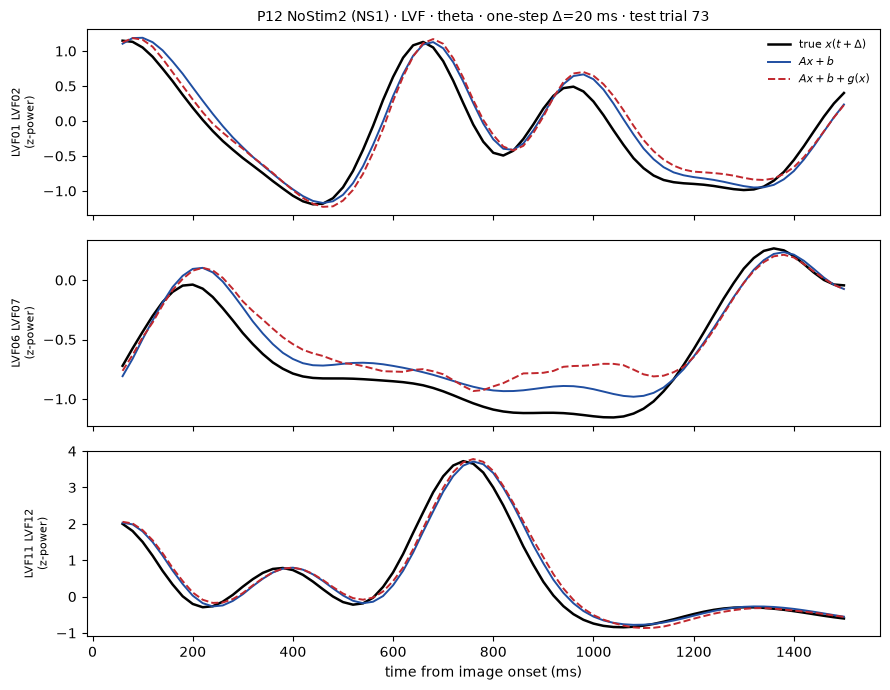

In [22]:
# ---------- POC part 2: horizon mini-sweep + trajectory figure ----------
# NOTE: with a 20-ms token stride, only multiples of 20 ms are realizable
# (spec's 10/50 ms horizons are not on the token grid; recorded as a deviation).
poc_horizons = [20, 40, 100, 200]
rows = []
models_at_h = {}
for h_ms in poc_horizons:
    hs = h_ms // TOKEN_STRIDE_MS
    Xtr_h, Ytr_h = make_pairs(z_r[tr], hs)
    Xva_h, Yva_h = make_pairs(z_r[va], hs)
    Xte_h, Yte_h = make_pairs(z_r[te], hs)
    A_h, b_h, lam_h = fit_ridge(Xtr_h, Ytr_h, Xva_h, Yva_h)
    R_tr = Ytr_h - ridge_predict(A_h, b_h, Xtr_h)
    R_va = Yva_h - ridge_predict(A_h, b_h, Xva_h)
    g_h = fit_residual_mlp(Xtr_h, R_tr, Xva_h, R_va)
    p_lin = ridge_predict(A_h, b_h, Xte_h)
    p_res = p_lin + mlp_predict(g_h, Xte_h)
    models_at_h[h_ms] = (A_h, b_h, g_h)
    for name, p in [("persistence", Xte_h), ("Ax+b", p_lin), ("Ax+b+g(x)", p_res)]:
        rows.append({"horizon_ms": h_ms, "model": name, **eval_all(Yte_h, p)})

poc_sweep = pd.DataFrame(rows)
display(poc_sweep.pivot(index="horizon_ms", columns="model", values="R2").round(4))

# ---------- Trajectory figure: one test trial, Δ=20 ms one-step predictions ----------
hs = 1
trial = te[0]
Xp, Yp = z_r[trial, :-hs, :], z_r[trial, hs:, :]
A20, b20, g20 = models_at_h[20]
p_lin = ridge_predict(A20, b20, Xp)
p_res = p_lin + mlp_predict(g20, Xp)
t_pred = token_t[hs:]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, ch in zip(axes, [0, 5, 10]):
    ax.plot(t_pred, Yp[:, ch], color=COLOR_TRUE, lw=1.8, label="true $x(t+\\Delta)$")
    ax.plot(t_pred, p_lin[:, ch], color=COLOR_LINEAR, lw=1.4, label="$Ax+b$")
    ax.plot(t_pred, p_res[:, ch], color=COLOR_RESIDUAL, lw=1.4, ls="--", label="$Ax+b+g(x)$")
    ax.set_ylabel(f"{ch_tbl.loc[clean_idx[region_mask_in_clean], 'pair_name'].iloc[ch]}\n(z-power)", fontsize=8)
axes[0].legend(loc="upper right", fontsize=8, frameon=False)
axes[0].set_title(f"P12 NoStim2 (NS1) · {POC_LEAD} · theta · one-step Δ=20 ms · test trial {trial}", fontsize=10)
axes[-1].set_xlabel("time from image onset (ms)")
fig.tight_layout()
fig.savefig(FIG_DIR / "poc_trajectory_P12_LVF_theta.png", dpi=200)
plt.show()


**Figure — POC one-step trajectories (P12 · LVF · θ · Δ = 20 ms).** Three example LVF channels from a single held-out test trial. Black = true z-scored theta power at $t+\Delta$; blue = frozen linear prediction $Ax+b$; dashed red = linear + learned residual $Ax+b+g(x)$. Both models track the true state almost perfectly at the 20-ms horizon — the blue and red curves are nearly indistinguishable from truth, showing that one token step of theta-power dynamics is essentially linear. The table above quantifies this across horizons: linear $R^2$ falls gracefully from ~0.98 (20 ms) as $\Delta$ grows, while persistence collapses much faster, and the residual MLP adds only a small correction (the "nonlinearity budget" is small).

In [21]:
# ---------- POC part 3: OOD (NS1-ID vs NS2-OOD, frozen model; spec §9-10 adapted) ----------
# NS2 = non-stimulated trials inside the Stim1 session (TrialDet 'Stimulation' == 0).
# Everything is FROZEN from NS1 training: normalization stats, A, b, lambda, g(x).
stim1_path = HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat"
stim1_cache = CACHE_DIR / "P12_Stim1.npz"

if stim1_cache.exists() or stim1_path.exists():
    try:
        if stim1_cache.exists():
            sess_stim = load_cached("P12_Stim1")
        else:
            sess_stim = load_session(stim1_path)
            cache_session(sess_stim, "P12_Stim1")
    except OSError as e:
        sess_stim = None
        print(f"Stim1 file still uploading/truncated - rerun later. ({e})")
else:
    sess_stim = None
    print("Stim1 file not available yet - run this cell once the upload completes.")

if sess_stim is not None:
    # Montages differ slightly across sessions (Stim1 has 152 pairs vs NoStim2's 151),
    # so align by PAIR NAME: the frozen model needs exactly the same 15 LVF channels.
    poc_pairs = sess["channels"]["pair_name"].to_numpy()[clean_idx[region_mask_in_clean]]
    stim_names = pd.Index(sess_stim["channels"]["pair_name"])
    assert all(p in stim_names for p in poc_pairs), "POC LVF pairs missing in Stim1 montage"
    stim_cols = stim_names.get_indexer(poc_pairs)
    n_ict = int(sess_stim["channels"]["ictal"].to_numpy()[stim_cols].sum())
    if n_ict:
        print(f"warning: {n_ict}/{len(poc_pairs)} POC pairs flagged ictal in Stim1 (kept for frozen-model comparability)")

    ns2_mask = sess_stim["trials"]["Stimulation"].to_numpy() == 0
    print(f"Stim1 session: {len(sess_stim['trials'])} trials, NS2 (non-stimulated) = {ns2_mask.sum()}")

    # identical preprocessing; SAME channels (by name) and NS1-train normalization stats
    d_ood = sess_stim["data"][ns2_mask][:, stim_cols, :]
    good_ood = ~np.isnan(d_ood).any(axis=(1, 2))          # drop aborted NaN-padded trials
    if (~good_ood).any():
        print(f"dropping {(~good_ood).sum()} NaN trial(s) in Stim1 NS2 set")
    pw_ood = band_power(d_ood[good_ood], sess_stim["fs"], PRIMARY_BAND)
    tok_ood_r, base_ood, _ = tokenize(pw_ood, sess_stim["time"])
    # frozen transform: reuse NS1 TRAINING baseline mean/sd (not NS2's own baseline)
    mu = base_r[tr].mean(axis=0); sd = base_r[tr].std(axis=0) + 1e-12
    z_ood = (tok_ood_r - mu[None, None, :]) / sd[None, None, :]

    h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS
    Xood, Yood = make_pairs(z_ood, h)
    pred_lin_ood = ridge_predict(A, b, Xood)
    pred_res_ood = pred_lin_ood + mlp_predict(g, Xood)

    poc_ood = pd.DataFrame({name: eval_all(Yood, p)
                            for name, p in [("persistence", Xood),
                                            ("Ax+b", pred_lin_ood),
                                            ("Ax+b+g(x)", pred_res_ood)]}).T
    print("\nOOD (NS2 trials, frozen NS1 model):")
    display(poc_ood.round(4))

    cmp = pd.concat({"ID (NS1 test)": poc_id["R2"], "OOD (NS2)": poc_ood["R2"]}, axis=1)
    cmp["delta_R2"] = cmp["OOD (NS2)"] - cmp["ID (NS1 test)"]
    print("\nID vs OOD (R^2, frozen model):")
    display(cmp.round(4))


Stim1 session: 383 trials, NS2 (non-stimulated) = 269

OOD (NS2 trials, frozen NS1 model):


,R2,NRMSE,resid_energy
persistence,0.9830,0.1284,0.0143
Ax+b,0.9817,0.1332,0.0154
Ax+b+g(x),0.9794,0.1413,0.0173



ID vs OOD (R^2, frozen model):


,ID (NS1 test),OOD (NS2),delta_R2
persistence,0.9788,0.9830,0.0041
Ax+b,0.9791,0.9817,0.0026
Ax+b+g(x),0.9785,0.9794,0.0009


Stim-session OOD (frozen NS1 model; NS2 = non-stim trials in stim blocks):


OOD      ID  delta_R2
model       horizon_ms                          
Ax+b        20          0.9817  0.9791    0.0026
            40          0.9292  0.9196    0.0096
            100         0.6266  0.5984    0.0282
            200         0.0838  0.1515   -0.0677
Ax+b+g(x)   20          0.9794  0.9785    0.0009
            40          0.9246  0.9179    0.0067
            100         0.6310  0.5952    0.0357
            200         0.1186  0.1576   -0.0390
persistence 20          0.9830  0.9788    0.0041
            40          0.9331  0.9168    0.0163
            100         0.6343  0.5371    0.0972
            200         0.0733 -0.2729    0.3462

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/stim_session_ood_P12_LVF_theta.png


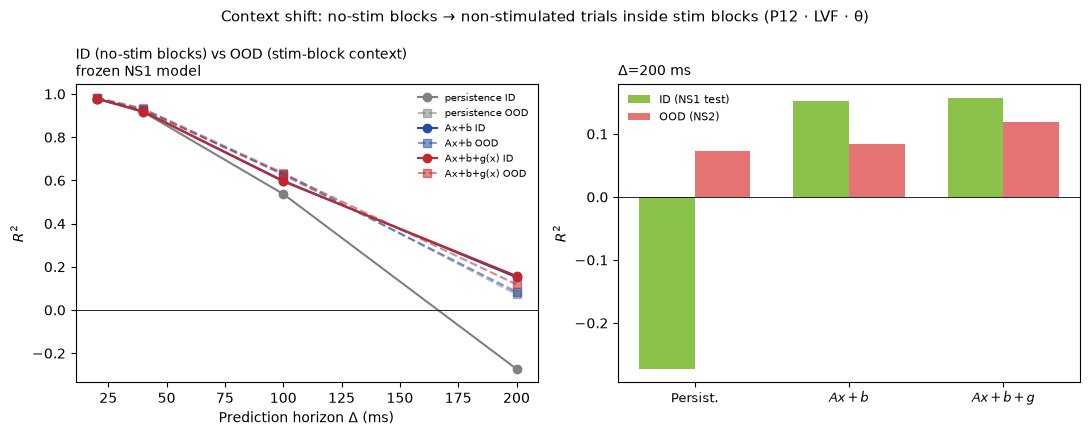

In [23]:
# ---------- Stim-session OOD across horizons (frozen NS1 models) + figure ----------
rows_s = []
for h_ms, (A_h, b_h, g_h) in models_at_h.items():
    hs = h_ms // TOKEN_STRIDE_MS
    Xo, Yo = make_pairs(z_ood, hs)
    p_l = ridge_predict(A_h, b_h, Xo)
    rows_s += [{"horizon_ms": h_ms, "split": "OOD", "model": "persistence", "R2": pop_r2(Yo, Xo)},
               {"horizon_ms": h_ms, "split": "OOD", "model": "Ax+b", "R2": pop_r2(Yo, p_l)},
               {"horizon_ms": h_ms, "split": "OOD", "model": "Ax+b+g(x)",
                "R2": pop_r2(Yo, p_l + mlp_predict(g_h, Xo))}]
ood_s = pd.DataFrame(rows_s).pivot(index=["model", "horizon_ms"], columns="split", values="R2")
id_s = poc_sweep.set_index(["model", "horizon_ms"])["R2"].rename("ID")
stim_cmp = ood_s.join(id_s)
stim_cmp["delta_R2"] = stim_cmp["OOD"] - stim_cmp["ID"]
stim_cmp.to_csv(RESULTS_DIR / "stim_session_ood_theta.csv")
print("Stim-session OOD (frozen NS1 model; NS2 = non-stim trials in stim blocks):")
display(stim_cmp.round(4))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4))
for model, colr in [("persistence", "gray"), ("Ax+b", COLOR_LINEAR), ("Ax+b+g(x)", COLOR_RESIDUAL)]:
    m = stim_cmp.loc[model].sort_index()
    axL.plot(m.index, m["ID"], "o-", color=colr, label=f"{model} ID")
    axL.plot(m.index, m["OOD"], "s--", color=colr, alpha=0.55, label=f"{model} OOD")
axL.axhline(0, color="k", lw=0.6)
axL.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axL.set_ylabel("$R^2$")
axL.legend(fontsize=7, frameon=False)
axL.set_title("ID (no-stim blocks) vs OOD (stim-block context)\nfrozen NS1 model", fontsize=10, loc="left")

h_show = 200
sub = stim_cmp.reset_index()
sub = sub[sub["horizon_ms"] == h_show].set_index("model").reindex(["persistence", "Ax+b", "Ax+b+g(x)"])
x = np.arange(len(sub)); w = 0.36
axR.bar(x - w/2, sub["ID"], w, color="#8bc34a", label="ID (NS1 test)")
axR.bar(x + w/2, sub["OOD"], w, color="#e57373", label="OOD (NS2)")
axR.axhline(0, color="k", lw=0.6)
axR.set_xticks(x); axR.set_xticklabels(["Persist.", "$Ax+b$", "$Ax+b+g$"], fontsize=9)
axR.set_ylabel("$R^2$"); axR.legend(fontsize=8, frameon=False)
axR.set_title(f"$\\Delta$={h_show} ms", fontsize=10, loc="left")
fig.suptitle("Context shift: no-stim blocks → non-stimulated trials inside stim blocks (P12 · LVF · θ)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"stim_session_ood_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "stim_session_ood_P12_LVF_theta.png")
plt.show()

**Figure — Stim-session context shift, LVF lead (frozen NS1 models).** Models are trained only on no-stim blocks (NS1) and applied frozen to non-stimulated trials recorded inside stimulation blocks (NS2). **Left:** $R^2$ vs prediction horizon; solid = ID (held-out NS1 trials), dashed = OOD (NS2). Up to Δ = 100 ms the OOD curves sit on top of (or slightly above) ID — the local linear map transfers across session context. **Right:** at Δ = 200 ms a mild degradation appears for the fitted models ($Ax+b$: −0.07 $R^2$) while persistence actually *improves* OOD, indicating the NS2 theta dynamics are somewhat flatter/slower rather than differently structured. Honest summary: in this lead the context shift is a long-horizon-only, mild effect.

NS2 clean channels matched in Stim1 montage: 112/114


,lead,area,n_ch,horizon_ms,R2_pers_ID,R2_pers_OOD,R2_lin_ID,R2_lin_OOD,delta_R2_lin
0,LAF,dorsolateral prefrontal,9,20,0.978,0.976,0.977,0.974,-0.003
1,LAF,dorsolateral prefrontal,9,100,0.537,0.479,0.580,0.355,-0.226
2,LAF,dorsolateral prefrontal,9,200,-0.355,-0.361,0.128,-1.489,-1.617
3,LAI,sensorimotor,11,20,0.981,0.977,0.981,0.976,-0.004
4,LAI,sensorimotor,11,100,0.586,0.501,0.610,0.514,-0.096
5,LAI,sensorimotor,11,200,-0.168,-0.305,0.143,-0.238,-0.382
6,LAO,parieto-occipital,8,20,0.973,0.972,0.972,0.972,-0.000
7,LAO,parieto-occipital,8,100,0.427,0.431,0.490,0.514,0.025
8,LAO,parieto-occipital,8,200,-0.558,-0.608,0.000,0.026,0.026
9,LPF,sensorimotor,13,20,0.980,0.982,0.981,0.981,-0.000


/tmp/ipykernel_70060/1536149245.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/stim_ood_all_leads_P12_theta.png


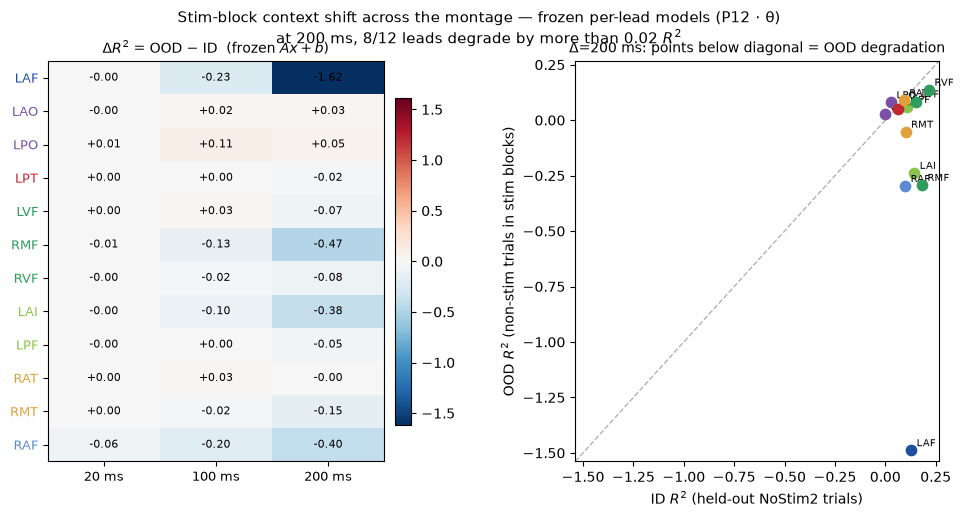

In [25]:
# ---------- Stim-session OOD in EVERY lead (train NoStim2 -> frozen -> Stim1 non-stim trials) ----------
# Channel alignment BY NAME (montages differ across sessions).
names_clean = sess["channels"]["pair_name"].to_numpy()[clean_idx]           # NS2 clean set (114)
pos_in_stim = pd.Index(sess_stim["channels"]["pair_name"]).get_indexer(names_clean)
matched = pos_in_stim >= 0
print(f"NS2 clean channels matched in Stim1 montage: {matched.sum()}/{len(names_clean)}")

# theta tokens for Stim1 non-stim trials on ALL matched channels (one filtering pass)
d_ood_all = sess_stim["data"][ns2_mask][:, pos_in_stim[matched], :]
good_o = ~np.isnan(d_ood_all).any(axis=(1, 2))
if (~good_o).any():
    print(f"dropping {(~good_o).sum()} NaN trial(s)")
pw_o_all = band_power(d_ood_all[good_o], sess_stim["fs"], PRIMARY_BAND)
tok_o_all, _, _ = tokenize(pw_o_all, sess_stim["time"])                     # (trials, 74, n_matched)
del d_ood_all, pw_o_all

lead_clean = sess["channels"]["lead"].to_numpy()[clean_idx]                 # lead per NS2 clean ch
rows_ls = []
for lead_ in sorted(set(lead_clean)):
    cols_ns2 = np.flatnonzero((lead_clean == lead_) & matched)              # into 114-clean axis
    if len(cols_ns2) < MIN_CH:
        continue
    cols_ood = np.searchsorted(np.flatnonzero(matched), cols_ns2)           # into matched axis
    # frozen normalization from NS2 TRAIN baselines
    mu_l = baseline[tr][:, cols_ns2].mean(axis=0)
    sd_l = baseline[tr][:, cols_ns2].std(axis=0) + 1e-12
    z_id = (tokens[:, :, cols_ns2] - mu_l) / sd_l
    z_od = (tok_o_all[:, :, cols_ood] - mu_l) / sd_l
    for h_ms in [20, 100, 200]:
        hs_ = h_ms // TOKEN_STRIDE_MS
        Xt_, Yt_ = make_pairs(z_id[tr], hs_)
        Xv_, Yv_ = make_pairs(z_id[va], hs_)
        Xi_, Yi_ = make_pairs(z_id[te], hs_)
        Xo_, Yo_ = make_pairs(z_od, hs_)
        A_, b_, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
        rows_ls.append(dict(lead=lead_, area=lead_area[lead_], n_ch=len(cols_ns2), horizon_ms=h_ms,
                            R2_pers_ID=pop_r2(Yi_, Xi_), R2_pers_OOD=pop_r2(Yo_, Xo_),
                            R2_lin_ID=pop_r2(Yi_, ridge_predict(A_, b_, Xi_)),
                            R2_lin_OOD=pop_r2(Yo_, ridge_predict(A_, b_, Xo_))))

ood_leads = pd.DataFrame(rows_ls)
ood_leads["delta_R2_lin"] = ood_leads["R2_lin_OOD"] - ood_leads["R2_lin_ID"]
ood_leads.to_csv(RESULTS_DIR / "stim_ood_all_leads_theta.csv", index=False)
display(ood_leads.round(3))

# --- figure: OOD-vs-ID delta heatmap + 200 ms scatter ---
ords = ood_leads.sort_values(["area", "lead"]).drop_duplicates("lead")["lead"].tolist()
D = ood_leads.pivot(index="lead", columns="horizon_ms", values="delta_R2_lin").loc[ords]
fig, (axH, axS) = plt.subplots(1, 2, figsize=(11.5, 5.2), gridspec_kw=dict(wspace=0.45))
dm = float(np.abs(D.to_numpy()).max())
im = axH.imshow(D.to_numpy(), cmap="RdBu_r", vmin=-dm, vmax=dm, aspect="auto")
axH.set_xticks(range(D.shape[1]), [f"{h} ms" for h in D.columns], fontsize=9)
axH.set_yticks(range(len(ords)), ords, fontsize=9)
for lbl, ld in zip(axH.get_yticklabels(), ords):
    lbl.set_color(AREA_COLORS[lead_area[ld]])
for i_ in range(D.shape[0]):
    for j_ in range(D.shape[1]):
        axH.text(j_, i_, f"{D.iat[i_, j_]:+.2f}", ha="center", va="center", fontsize=8)
axH.set_title("$\\Delta R^2$ = OOD $-$ ID  (frozen $Ax+b$)", fontsize=10)
fig.colorbar(im, ax=axH, fraction=0.045, pad=0.03)

sub2 = ood_leads[ood_leads.horizon_ms == 200]
for _, r_ in sub2.iterrows():
    axS.scatter(r_.R2_lin_ID, r_.R2_lin_OOD, s=55, color=AREA_COLORS[r_.area], zorder=3)
    axS.annotate(r_.lead, (r_.R2_lin_ID, r_.R2_lin_OOD), fontsize=7.5,
                 xytext=(4, 3), textcoords="offset points")
lims = [min(sub2.R2_lin_ID.min(), sub2.R2_lin_OOD.min()) - 0.05,
        max(sub2.R2_lin_ID.max(), sub2.R2_lin_OOD.max()) + 0.05]
axS.plot(lims, lims, color="0.7", lw=1, ls="--")
axS.set_xlim(lims); axS.set_ylim(lims)
axS.set_xlabel("ID $R^2$ (held-out NoStim2 trials)")
axS.set_ylabel("OOD $R^2$ (non-stim trials in stim blocks)")
axS.set_title("$\\Delta$=200 ms: points below diagonal = OOD degradation", fontsize=10)

n_deg = int((sub2["delta_R2_lin"] < -0.02).sum())
fig.suptitle(f"Stim-block context shift across the montage — frozen per-lead models (P12 · θ)\n"
             f"at 200 ms, {n_deg}/{len(sub2)} leads degrade by more than 0.02 $R^2$", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"stim_ood_all_leads_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "stim_ood_all_leads_P12_theta.png")
plt.show()

**Figure — Stim-block context shift across the whole montage (per-lead frozen models, P12 · θ).** Each lead with ≥5 clean channels gets its own linear model trained on NoStim2 trials and applied frozen to non-stimulated trials inside stim blocks (channels matched by name across montages, 112/114). **Left (heatmap):** ΔR² = OOD − ID per lead × horizon; blue = degradation. At Δ = 20 ms nothing degrades — one-step dynamics are context-invariant everywhere. At Δ = 200 ms, 8/12 leads degrade by >0.02 $R^2$, and the effect is strongly **frontal-dominant**: LAF (dlPFC) −1.62, RMF −0.47, RAF −0.40, LAI −0.38, while LVF barely moves (−0.07). **Right (scatter):** ID vs OOD $R^2$ at 200 ms, colored by anatomical area; points below the diagonal degrade. This is the first strong positive context-shift result in this dataset: being in a stimulation block reshapes *long-horizon* dynamics specifically in prefrontal leads. Caveat: single patient, and LAF is one 11-channel lead — trial-composition differences (conflict mix, session drift) are not yet ruled out.

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/A_matrix_diagnostics_P12_LVF_theta.png


,spectral_radius,n_unstable,max_sv,eff_rank,cond,median_tau_ms,max_stable_tau_ms
horizon_ms,,,,,,,
20,1.017,1,1.173,14.962,1.418,1377.396,2291.274
40,0.973,0,1.222,14.857,1.985,650.304,1486.653
100,0.821,0,1.665,14.072,5.170,284.218,507.408
200,0.527,0,2.151,10.074,44.840,179.444,311.977


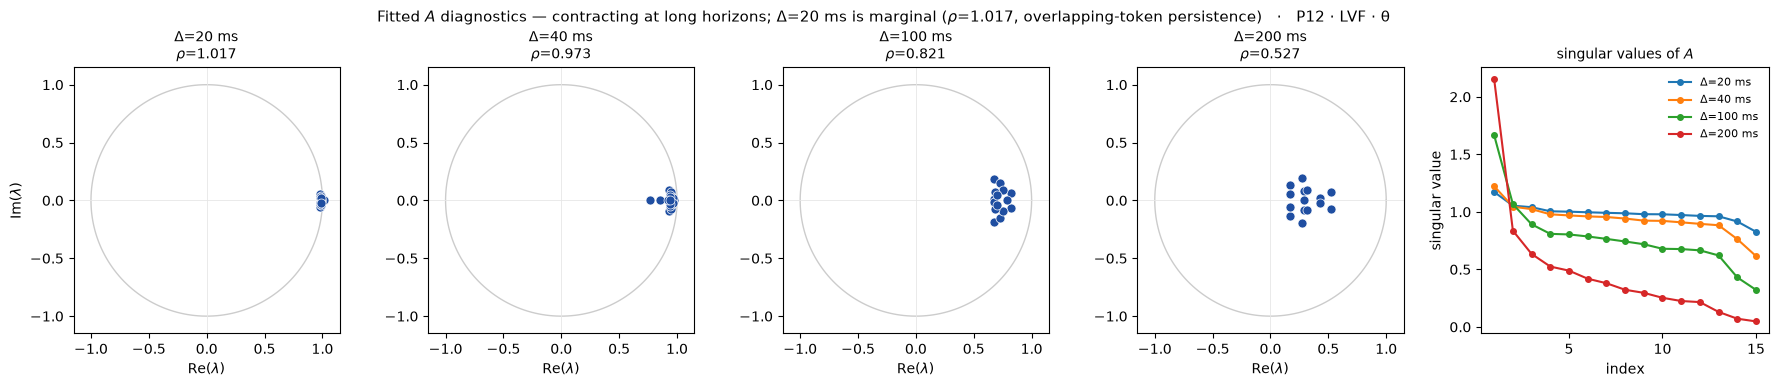

In [28]:
# ---------- A-matrix diagnostics: eigenvalues, timescales, singular values (spec §18) ----------
def eff_rank(s):
    """Effective rank = exp(entropy of normalized singular values)."""
    p_ = s / s.sum()
    return float(np.exp(-(p_ * np.log(p_ + 1e-300)).sum()))

diag_rows = []
fig, axes = plt.subplots(1, len(models_at_h) + 1, figsize=(4.2 * (len(models_at_h) + 1) - 3, 3.9))
th = np.linspace(0, 2 * np.pi, 200)
for k, (h_ms, (A_h, b_h, _)) in enumerate(sorted(models_at_h.items())):
    ev = np.linalg.eigvals(A_h)
    sv = np.linalg.svd(A_h, compute_uv=False)
    rho = np.abs(ev).max()
    # continuous-time decay timescale tau = -Δ / ln|λ| (stable modes only; |λ|>=1 excluded)
    lam_mag = np.abs(ev)
    stable = lam_mag < 1.0
    tau = -h_ms / np.log(lam_mag[stable])
    diag_rows.append(dict(horizon_ms=h_ms, spectral_radius=rho, n_unstable=int((~stable).sum()),
                          max_sv=sv[0], eff_rank=eff_rank(sv), cond=sv[0] / sv[-1],
                          median_tau_ms=float(np.median(tau)), max_stable_tau_ms=float(tau.max())))
    ax = axes[k]
    ax.plot(np.cos(th), np.sin(th), color="0.8", lw=1)
    ax.scatter(ev.real, ev.imag, s=42, color=COLOR_LINEAR, zorder=3, edgecolor="white", lw=0.5)
    ax.axhline(0, color="0.9", lw=0.6); ax.axvline(0, color="0.9", lw=0.6)
    ax.set_aspect("equal"); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
    ax.set_title(f"$\\Delta$={h_ms} ms\n$\\rho$={rho:.3f}", fontsize=10)
    ax.set_xlabel("Re($\\lambda$)")
    if k == 0:
        ax.set_ylabel("Im($\\lambda$)")

axs_sv = axes[-1]
for h_ms, (A_h, _, _) in sorted(models_at_h.items()):
    sv = np.linalg.svd(A_h, compute_uv=False)
    axs_sv.plot(np.arange(1, len(sv) + 1), sv, "o-", ms=4, label=f"$\\Delta$={h_ms} ms")
axs_sv.set_xlabel("index"); axs_sv.set_ylabel("singular value")
axs_sv.legend(fontsize=8, frameon=False)
axs_sv.set_title("singular values of $A$", fontsize=10)

A_diag = pd.DataFrame(diag_rows).set_index("horizon_ms")
A_diag.to_csv(RESULTS_DIR / "A_matrix_diagnostics_LVF_theta.csv")
rho20 = A_diag.loc[20, "spectral_radius"]
fig.suptitle(f"Fitted $A$ diagnostics — contracting at long horizons; $\\Delta$=20 ms is marginal "
             f"($\\rho$={rho20:.3f}, overlapping-token persistence)   ·   P12 · LVF · θ", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"A_matrix_diagnostics_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "A_matrix_diagnostics_P12_LVF_theta.png")
display(A_diag.round(3))
plt.show()

**Figure — Diagnostics of the fitted linear map $A$ (P12 · LVF · θ).** First four panels: eigenvalues of $A$ in the complex plane (gray = unit circle), one panel per horizon. The spectrum is a cluster of nearly-real positive eigenvalues — smoothed-power dynamics with no oscillatory modes at the token scale. Spectral radius shrinks with horizon: ρ = 1.017 → 0.973 → 0.821 → 0.527 for Δ = 20/40/100/200 ms. The single marginally-unstable mode at Δ = 20 ms reflects overlapping-token persistence (40-ms window, 20-ms stride), not genuine instability; at all longer horizons the map is strictly contracting. **Rightmost panel:** singular values of $A$; effective rank drops from ~15 (20 ms) to ~10 (200 ms) and conditioning worsens (κ ≈ 45 at 200 ms). Implied decay timescales of the stable modes (τ = −Δ/ln|λ|) shorten from a median of ~1.4 s at 20 ms to ~180 ms at 200 ms — the longer-horizon maps capture faster, lower-dimensional collective dynamics.

stim trials: 114 | onset rel. image: median 0 ms (range -618..401) | duration: median 600 ms
raw-voltage RMS in stim window: 1.3x the non-stim level -> no gross artifact (theta filtfilt smears it ~±200 ms; interpret stim-window tokens with caution)

frozen Ax+b R^2 (Δ=20 ms): non-stim trials 0.9817 | stim trials ALL 0.9807 | stim trials excl. ±250 ms around stim 0.9764


/tmp/ipykernel_70060/1184420636.py:91: RuntimeWarning: Mean of empty slice
  m_s, m_ns = np.nanmean(al_s, axis=0), np.nanmean(al_ns, axis=0)
/tmp/ipykernel_70060/1184420636.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/stim_trials_artifact_aware_P12_LVF_theta.png


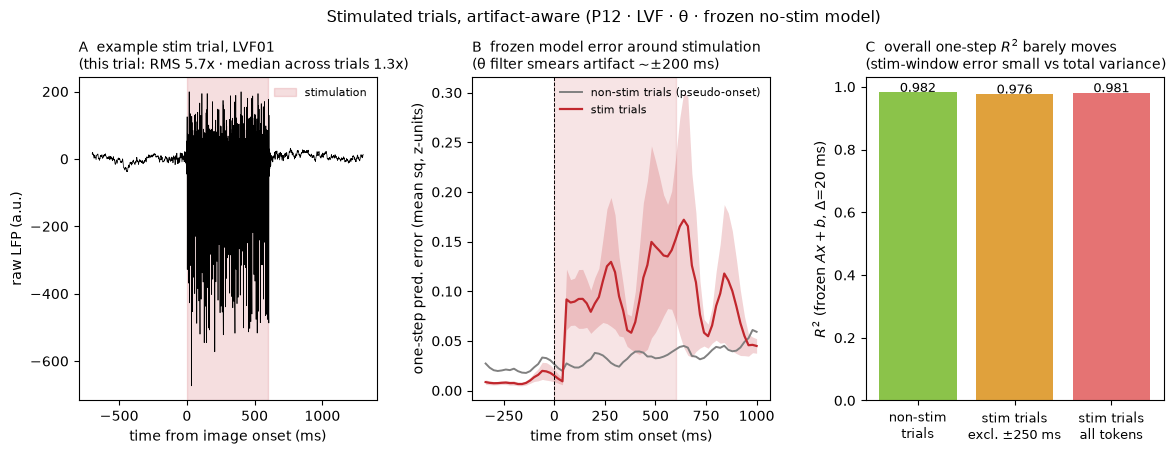

In [32]:
# ---------- STIMULATED trials (artifact-aware): does the frozen model break at stim onset? ----------
# Stimulation timing from NEV clocks: onset/offset relative to image onset (s).
td_s = sess_stim["trials"]
stim_mask = td_s["Stimulation"].to_numpy() == 1
rel_on = (td_s["Stim onset NEV"] - td_s["Image Onset NEV"]).to_numpy()
rel_off = (td_s["Stim offset NEV"] - td_s["Image Onset NEV"]).to_numpy()
on_s, off_s = rel_on[stim_mask], rel_off[stim_mask]
dur_s = off_s - on_s
print(f"stim trials: {stim_mask.sum()} | onset rel. image: median {np.median(on_s)*1000:.0f} ms "
      f"(range {on_s.min()*1000:.0f}..{on_s.max()*1000:.0f}) | duration: median {np.median(dur_s)*1000:.0f} ms")

# --- theta tokens for STIM trials on the frozen LVF channels (same by-name columns) ---
d_stim = sess_stim["data"][stim_mask][:, stim_cols, :]
good_s = ~np.isnan(d_stim).any(axis=(1, 2))
if (~good_s).any():
    print(f"dropping {(~good_s).sum()} NaN stim trial(s)")
pw_s = band_power(d_stim[good_s], sess_stim["fs"], PRIMARY_BAND)
tok_s, _, _ = tokenize(pw_s, sess_stim["time"])
z_s = (tok_s - mu[None, None, :]) / sd[None, None, :]          # FROZEN no-stim normalization
on_ms, off_ms = on_s[good_s] * 1000.0, off_s[good_s] * 1000.0

# --- artifact check: raw-voltage RMS inside the stim window vs matched non-stim window ---
t_ms_axis = sess_stim["time"] * 1000.0
rms_stim, rms_ctrl = [], []
rng_a = np.random.default_rng(RANDOM_SEED)
d_ns = sess_stim["data"][ns2_mask][:, stim_cols, :]
for k in range(int(good_s.sum())):
    win = (t_ms_axis >= on_ms[k]) & (t_ms_axis <= off_ms[k])
    if win.sum() < 10:
        continue
    rms_stim.append(np.sqrt((d_stim[good_s][k][:, win] ** 2).mean()))
    j = rng_a.integers(0, d_ns.shape[0])
    rms_ctrl.append(np.sqrt((d_ns[j][:, win] ** 2).mean()))
rms_ratio = np.median(rms_stim) / np.median(rms_ctrl)
print(f"raw-voltage RMS in stim window: {rms_ratio:.1f}x the non-stim level "
      f"-> {'ARTIFACT present' if rms_ratio > 1.5 else 'no gross artifact'} "
      f"(theta filtfilt smears it ~±200 ms; interpret stim-window tokens with caution)")

# --- one-step (Δ=20 ms) prediction error vs time from STIM ONSET (frozen model) ---
A20f, b20f, _ = models_at_h[20]
def token_err(z_tok):
    """per-trial, per-token squared error of frozen Ax+b, averaged over channels."""
    pred = ridge_predict(A20f, b20f, z_tok[:, :-1, :].reshape(-1, z_tok.shape[-1]))
    err = ((z_tok[:, 1:, :].reshape(-1, z_tok.shape[-1]) - pred) ** 2).mean(axis=1)
    return err.reshape(z_tok.shape[0], -1)                     # (trials, tokens-1)

err_s = token_err(z_s)
err_ns = token_err(z_ood)                                      # non-stim trials, same frozen model
tok_time = token_t[1:]                                         # time of predicted token

LAGS = np.arange(-500, 1001, TOKEN_STRIDE_MS)                  # ms relative to stim onset
def align(err, onsets_ms):
    M = np.full((err.shape[0], len(LAGS)), np.nan)
    for k, on in enumerate(onsets_ms):
        for li, lag in enumerate(LAGS):
            idx = np.argmin(np.abs(tok_time - (on + lag)))
            if abs(tok_time[idx] - (on + lag)) <= TOKEN_STRIDE_MS / 2:
                M[k, li] = err[k, idx]
    return M

al_s = align(err_s, on_ms)
pseudo_on = rng_a.choice(on_ms, size=err_ns.shape[0])          # matched pseudo-onsets for non-stim
al_ns = align(err_ns, pseudo_on)

# --- overall R^2 on stim trials, with and without the artifact-contaminated window ---
Xs_, Ys_ = z_s[:, :-1, :].reshape(-1, z_s.shape[-1]), z_s[:, 1:, :].reshape(-1, z_s.shape[-1])
r2_stim_all = pop_r2(Ys_, ridge_predict(A20f, b20f, Xs_))
excl = np.ones(err_s.shape, bool)                              # (trials, tokens-1)
for k in range(err_s.shape[0]):
    excl[k] = ~((tok_time >= on_ms[k] - 250) & (tok_time <= off_ms[k] + 250))
mask_flat = excl.reshape(-1)
r2_stim_excl = pop_r2(Ys_.reshape(err_s.shape[0], -1, z_s.shape[-1])[excl],
                      ridge_predict(A20f, b20f, Xs_.reshape(err_s.shape[0], -1, z_s.shape[-1])[excl]))
r2_ns = pop_r2(Yood, ridge_predict(A20f, b20f, Xood))
print(f"\nfrozen Ax+b R^2 (Δ=20 ms): non-stim trials {r2_ns:.4f} | stim trials ALL {r2_stim_all:.4f} "
      f"| stim trials excl. ±250 ms around stim {r2_stim_excl:.4f}")

# --- figure ---
fig, axs = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw=dict(wspace=0.32))
k_ex = int(np.argmax(dur_s[good_s]))                           # example with longest stim train
show = (t_ms_axis >= on_ms[k_ex] - 700) & (t_ms_axis <= off_ms[k_ex] + 700)
axs[0].plot(t_ms_axis[show], d_stim[good_s][k_ex, 0, show], lw=0.5, color="black")
axs[0].axvspan(on_ms[k_ex], off_ms[k_ex], color="#c1272d", alpha=0.15, label="stimulation")
axs[0].set_xlabel("time from image onset (ms)"); axs[0].set_ylabel("raw LFP (a.u.)")
axs[0].legend(fontsize=8, frameon=False)
ex_win = (t_ms_axis >= on_ms[k_ex]) & (t_ms_axis <= off_ms[k_ex])
ex_ratio = np.sqrt((d_stim[good_s][k_ex][:, ex_win] ** 2).mean()) / np.median(rms_ctrl)
axs[0].set_title(f"A  example stim trial, {poc_pairs[0].split()[0]}\n(this trial: RMS {ex_ratio:.1f}x · median across trials {rms_ratio:.1f}x)",
                 loc="left", fontsize=10)

m_s, m_ns = np.nanmean(al_s, axis=0), np.nanmean(al_ns, axis=0)
se_s = np.nanstd(al_s, axis=0) / np.sqrt(np.sum(np.isfinite(al_s), axis=0).clip(1))
axs[1].axvspan(0, np.median(dur_s) * 1000, color="#c1272d", alpha=0.12)
axs[1].plot(LAGS, m_ns, color="gray", lw=1.4, label="non-stim trials (pseudo-onset)")
axs[1].plot(LAGS, m_s, color="#c1272d", lw=1.6, label="stim trials")
axs[1].fill_between(LAGS, m_s - se_s, m_s + se_s, color="#c1272d", alpha=0.2, lw=0)
axs[1].axvline(0, color="k", lw=0.7, ls="--")
axs[1].set_xlabel("time from stim onset (ms)"); axs[1].set_ylabel("one-step pred. error (mean sq, z-units)")
axs[1].legend(fontsize=8, frameon=False)
axs[1].set_title("B  frozen model error around stimulation\n(θ filter smears artifact ~±200 ms)",
                 loc="left", fontsize=10)

vals = [r2_ns, r2_stim_excl, r2_stim_all]
labs = ["non-stim\ntrials", "stim trials\nexcl. ±250 ms", "stim trials\nall tokens"]
axs[2].bar(range(3), vals, color=["#8bc34a", "#e0a13c", "#e57373"])
for i_, v_ in enumerate(vals):
    axs[2].text(i_, v_ + 0.002, f"{v_:.3f}", ha="center", fontsize=9)
axs[2].set_title("C  overall one-step $R^2$ barely moves\n(stim-window error small vs total variance)", loc="left", fontsize=10)
axs[2].set_xticks(range(3), labs, fontsize=9)
axs[2].set_ylabel("$R^2$ (frozen $Ax+b$, $\\Delta$=20 ms)")
fig.suptitle("Stimulated trials, artifact-aware (P12 · LVF · θ · frozen no-stim model)", fontsize=11.5, y=1.04)

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"stim_trials_artifact_aware_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")

print("saved ->", FIG_DIR / "stim_trials_artifact_aware_P12_LVF_theta.png")
plt.show()

**Figure — Stimulated trials, artifact-aware (P12 · LVF · θ · frozen no-stim model).** Stimulation is delivered around image onset (median onset 0 ms, ~600-ms trains, 114 trials). **A:** example raw LVF trace with the stim window shaded; median raw RMS inside the window is only 1.3× the non-stim level (worst trials up to ~6×), but the θ band-pass filter smears any residual artifact ±200 ms, so tokens inside the window carry a caveat. **B:** frozen-model one-step prediction error aligned to stim onset (red) vs pseudo-onset-aligned non-stim trials (gray): error rises ~4× during the stim train and returns to baseline after offset — the perturbation is real, brief, and time-locked. **C:** overall one-step $R^2$ (Δ = 20 ms) barely moves: 0.982 (non-stim) vs 0.981 (stim trials, all tokens) vs 0.976 (excluding ±250 ms around stim) — the stim-window error is large locally but small relative to total variance, so local linearization survives on stimulated trials outside the immediate stimulation window.

### Two independent OOD axes

This notebook probes context shift along **two separate axes**, both with the same frozen-model protocol (fit $A$, $b$, $\lambda$, $g$ and normalization on the training context only, never touch OOD data during fitting):

1. **Task-condition (behavioral) OOD** — next cells: train on **low-conflict** MSIT trials (Conflict ≤ 1, "easy"), predict frozen on **high-conflict** trials (Conflict ≥ 2, "hard"). Result: full transfer — no degradation at any horizon (an honest negative: cognitive conflict does not change local θ-power dynamics).
2. **Stimulation-context OOD** — earlier cells: train on no-stim blocks, predict frozen on non-stimulated trials inside stim blocks. Result: long-horizon, frontal-dominant degradation.

In [33]:
# ---------- POC part 4: conflict-shift OOD (panel-C design; runs on NoStim2 alone) ----------
# Behavioral context shift: train/ID on LOW-conflict trials, test OOD on HIGH-conflict
# trials with the SAME frozen model (A, b, lambda, g and normalization stats).
conf = sess["trials"]["Conflict"].to_numpy()
print("Conflict levels:", {int(k): int(v) for k, v in zip(*np.unique(conf, return_counts=True))})
low_trials = np.flatnonzero(conf <= 1)     # congruent / low interference
high_trials = np.flatnonzero(conf >= 2)    # high interference
print(f"low-conflict trials: {len(low_trials)}, high-conflict trials: {len(high_trials)}")

# split LOW-conflict trials 60/20/20; HIGH-conflict is entirely held out (OOD)
tr_lo, va_lo, te_lo = trial_split(len(low_trials))
tr_lo, va_lo, te_lo = low_trials[tr_lo], low_trials[va_lo], low_trials[te_lo]

# frozen normalization from LOW-conflict TRAINING baselines
mu_lo = base_r[tr_lo].mean(axis=0); sd_lo = base_r[tr_lo].std(axis=0) + 1e-12
z_c = (tok_r - mu_lo[None, None, :]) / sd_lo[None, None, :]

h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS
Xtr_c, Ytr_c = make_pairs(z_c[tr_lo], h)
Xva_c, Yva_c = make_pairs(z_c[va_lo], h)
Xid_c, Yid_c = make_pairs(z_c[te_lo], h)          # ID test: held-out low conflict
Xod_c, Yod_c = make_pairs(z_c[high_trials], h)    # OOD test: high conflict

A_c, b_c, lam_c = fit_ridge(Xtr_c, Ytr_c, Xva_c, Yva_c)
R_tr_c = Ytr_c - ridge_predict(A_c, b_c, Xtr_c)
R_va_c = Yva_c - ridge_predict(A_c, b_c, Xva_c)
g_c = fit_residual_mlp(Xtr_c, R_tr_c, Xva_c, R_va_c)

res = {}
for split, (Xs, Ys) in [("ID (low conflict)", (Xid_c, Yid_c)),
                        ("OOD (high conflict)", (Xod_c, Yod_c))]:
    p_l = ridge_predict(A_c, b_c, Xs)
    p_r = p_l + mlp_predict(g_c, Xs)
    res[split] = {"persistence": pop_r2(Ys, Xs), "Ax+b": pop_r2(Ys, p_l), "Ax+b+g(x)": pop_r2(Ys, p_r)}

conflict_ood = pd.DataFrame(res)
conflict_ood["delta_R2"] = conflict_ood["OOD (high conflict)"] - conflict_ood["ID (low conflict)"]
print(f"\nConflict-shift OOD (Δ={PRIMARY_HORIZON_MS} ms, frozen low-conflict model, R^2):")
display(conflict_ood.round(4))


Conflict levels: {0: 32, 1: 32, 2: 32, 3: 31}
low-conflict trials: 64, high-conflict trials: 63

Conflict-shift OOD (Δ=20 ms, frozen low-conflict model, R^2):


,ID (low conflict),OOD (high conflict),delta_R2
persistence,0.9819,0.9809,-0.0010
Ax+b,0.9774,0.9794,0.0020
Ax+b+g(x),0.9760,0.9769,0.0008


In [34]:
# ---------- Conflict-shift OOD across horizons (where dynamics matter) ----------
rows_c = []
for h_ms in [20, 40, 100, 200]:
    hs = h_ms // TOKEN_STRIDE_MS
    Xt, Yt = make_pairs(z_c[tr_lo], hs)
    Xv, Yv = make_pairs(z_c[va_lo], hs)
    Xi, Yi = make_pairs(z_c[te_lo], hs)
    Xo, Yo = make_pairs(z_c[high_trials], hs)
    A_hc, b_hc, _ = fit_ridge(Xt, Yt, Xv, Yv)
    g_hc = fit_residual_mlp(Xt, Yt - ridge_predict(A_hc, b_hc, Xt),
                            Xv, Yv - ridge_predict(A_hc, b_hc, Xv))
    for split, Xs, Ys in [("ID", Xi, Yi), ("OOD", Xo, Yo)]:
        p_l = ridge_predict(A_hc, b_hc, Xs)
        rows_c += [{"horizon_ms": h_ms, "split": split, "model": "persistence", "R2": pop_r2(Ys, Xs)},
                   {"horizon_ms": h_ms, "split": split, "model": "Ax+b", "R2": pop_r2(Ys, p_l)},
                   {"horizon_ms": h_ms, "split": split, "model": "Ax+b+g(x)",
                    "R2": pop_r2(Ys, p_l + mlp_predict(g_hc, Xs))}]

cs = pd.DataFrame(rows_c).pivot(index=["model", "horizon_ms"], columns="split", values="R2")
cs["delta_R2"] = cs["OOD"] - cs["ID"]
print("Conflict-shift OOD across horizons (frozen low-conflict model, R^2):")
display(cs.round(4))


Conflict-shift OOD across horizons (frozen low-conflict model, R^2):


split                       ID     OOD  delta_R2
model       horizon_ms                          
Ax+b        20          0.9774  0.9794    0.0020
            40          0.9123  0.9207    0.0085
            100         0.5504  0.6063    0.0559
            200         0.0129  0.1244    0.1116
Ax+b+g(x)   20          0.9760  0.9769    0.0008
            40          0.9101  0.9159    0.0058
            100         0.5449  0.6026    0.0576
            200        -0.0093  0.1212    0.1305
persistence 20          0.9819  0.9809   -0.0010
            40          0.9287  0.9260   -0.0027
            100         0.6010  0.6013    0.0003
            200        -0.1337 -0.0905    0.0432

/tmp/ipykernel_70060/1962298528.py:76: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axs[0, 2].plot(mse_df.index, mse_df[col_], "o-", color=MODEL_COLORS[key], label=lab_,


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/residual_analysis_P12_LVF_theta.png


,context,horizon_ms,model,median,p95
0,ID,20,persistence,0.1514,0.4886
1,ID,20,Ax+b,0.1556,0.5148
2,ID,20,Ax+b+g(x),0.1596,0.5148
3,ID,200,persistence,1.1723,4.1266
4,ID,200,Ax+b,0.9854,3.2117
5,ID,200,Ax+b+g(x),1.0014,3.3492
6,ID (low conflict),200,Ax+b,0.9579,3.6517
7,OOD (high conflict),200,Ax+b,0.9755,2.6100
8,ID (no-stim blocks),200,Ax+b,0.9854,3.2117
9,OOD (stim blocks),200,Ax+b,0.6956,2.3460


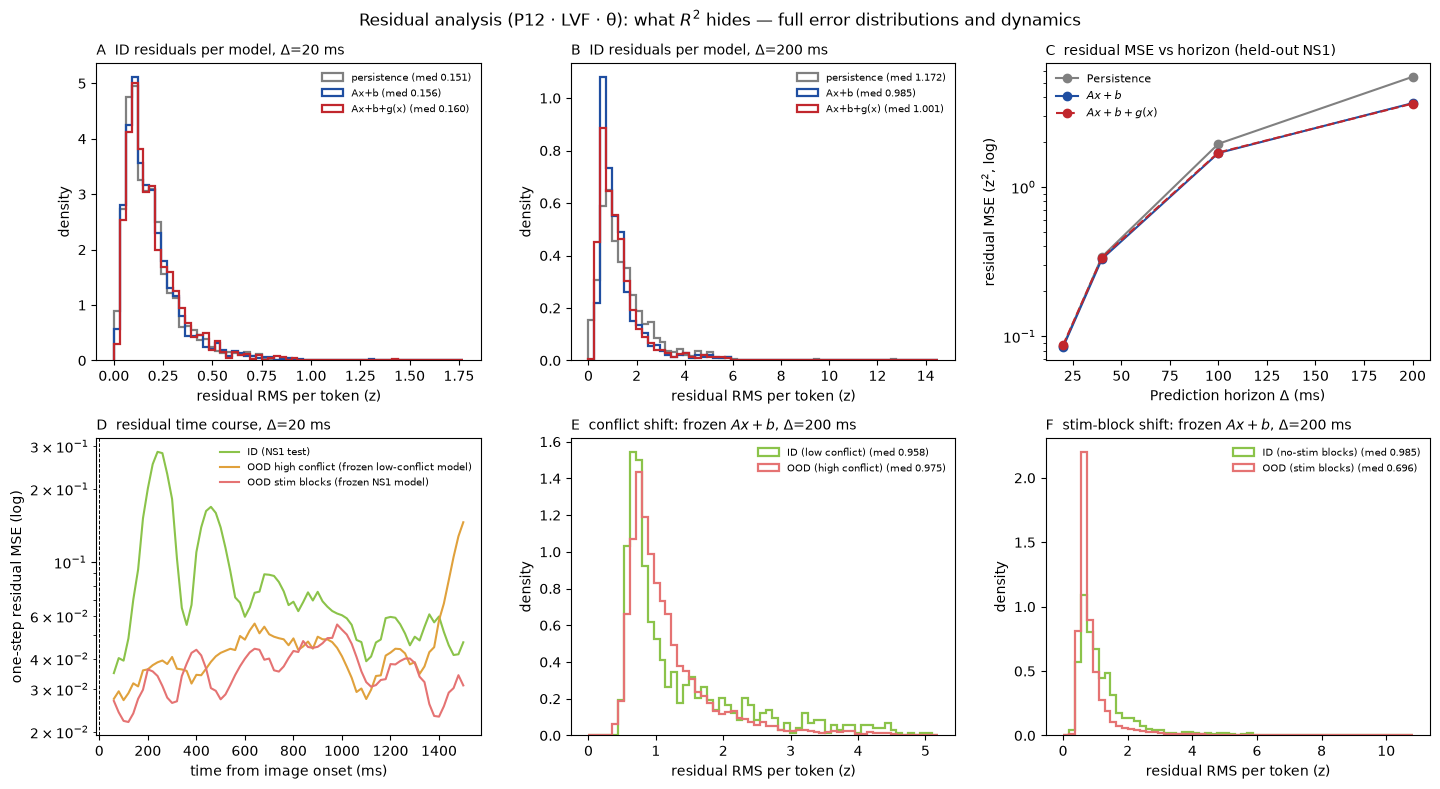

In [35]:
# ---------- Residual analysis: distributions & time courses (beyond R^2) ----------
# Per-token residual RMS across channels (z-units): one number per predicted token.
def resid_norms(Y, P):
    return np.sqrt(((Y - P) ** 2).mean(axis=1))

# --- (1) ID residuals per model, Δ=20 and 200 ms (held-out NS1 trials, LVF) ---
res_id = {}
for h_ms in (20, 200):
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xi, Yi = make_pairs(z_r[te], hs_)
    A_h, b_h, g_h = models_at_h[h_ms]
    p_l = ridge_predict(A_h, b_h, Xi)
    res_id[h_ms] = {"persistence": resid_norms(Yi, Xi),
                    "Ax+b": resid_norms(Yi, p_l),
                    "Ax+b+g(x)": resid_norms(Yi, p_l + mlp_predict(g_h, Xi))}

# --- (2) residual MSE vs horizon (the complement of the R^2 curves) ---
mse_rows = []
for h_ms, (A_h, b_h, g_h) in sorted(models_at_h.items()):
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xi, Yi = make_pairs(z_r[te], hs_)
    p_l = ridge_predict(A_h, b_h, Xi)
    mse_rows.append(dict(horizon_ms=h_ms,
                         persistence=float(((Yi - Xi) ** 2).mean()),
                         lin=float(((Yi - p_l) ** 2).mean()),
                         lin_g=float(((Yi - p_l - mlp_predict(g_h, Xi)) ** 2).mean())))
mse_df = pd.DataFrame(mse_rows).set_index("horizon_ms")

# --- (3) frozen-model OOD residuals at Δ=200 ms, both context axes ---
hs_ = 200 // TOKEN_STRIDE_MS
# conflict axis: refit low-conflict model at 200 ms (train/val = low-conflict only)
Xt_c2, Yt_c2 = make_pairs(z_c[tr_lo], hs_); Xv_c2, Yv_c2 = make_pairs(z_c[va_lo], hs_)
A_c2, b_c2, _ = fit_ridge(Xt_c2, Yt_c2, Xv_c2, Yv_c2)
Xi_c2, Yi_c2 = make_pairs(z_c[te_lo], hs_)
Xo_c2, Yo_c2 = make_pairs(z_c[high_trials], hs_)
rn_conf = {"ID (low conflict)": resid_norms(Yi_c2, ridge_predict(A_c2, b_c2, Xi_c2)),
           "OOD (high conflict)": resid_norms(Yo_c2, ridge_predict(A_c2, b_c2, Xo_c2))}
# stim axis: frozen NS1 model
A_s2, b_s2, _ = models_at_h[200]
Xi_s2, Yi_s2 = make_pairs(z_r[te], hs_)
Xo_s2, Yo_s2 = make_pairs(z_ood, hs_)
rn_stim = {"ID (no-stim blocks)": resid_norms(Yi_s2, ridge_predict(A_s2, b_s2, Xi_s2)),
           "OOD (stim blocks)": resid_norms(Yo_s2, ridge_predict(A_s2, b_s2, Xo_s2))}

# --- (4) residual time course within trial (Δ=20 ms, mean over trials & channels) ---
def time_course(z_split, A_, b_):
    X_, Y_ = z_split[:, :-1, :], z_split[:, 1:, :]
    return ((Y_ - (X_ @ A_.T + b_)) ** 2).mean(axis=(0, 2))
A20_, b20_, _ = models_at_h[20]
tc = {"ID (NS1 test)": (time_course(z_r[te], A20_, b20_), "#8bc34a"),
      "OOD high conflict (frozen low-conflict model)": (time_course(z_c[high_trials], A_c, b_c), "#e0a13c"),
      "OOD stim blocks (frozen NS1 model)": (time_course(z_ood, A20_, b20_), "#e57373")}
tt = token_t[1:]

# --- figure ---
MODEL_COLORS = {"persistence": "gray", "Ax+b": COLOR_LINEAR, "Ax+b+g(x)": COLOR_RESIDUAL}
fig, axs = plt.subplots(2, 3, figsize=(14.5, 8))

def hist_panel(ax, dists, colors, title, xlabel):
    hi = max(np.percentile(v, 99.5) for v in dists.values())
    bins = np.linspace(0, hi, 60)
    for (lab, v), c in zip(dists.items(), colors):
        ax.hist(v, bins=bins, density=True, histtype="step", lw=1.6, color=c,
                label=f"{lab} (med {np.median(v):.3f})")
    ax.legend(fontsize=7.5, frameon=False)
    ax.set_xlabel(xlabel); ax.set_ylabel("density")
    ax.set_title(title, loc="left", fontsize=10)

hist_panel(axs[0, 0], res_id[20], [MODEL_COLORS[k] for k in res_id[20]],
           "A  ID residuals per model, $\\Delta$=20 ms", "residual RMS per token (z)")
hist_panel(axs[0, 1], res_id[200], [MODEL_COLORS[k] for k in res_id[200]],
           "B  ID residuals per model, $\\Delta$=200 ms", "residual RMS per token (z)")

for col_, lab_ in [("persistence", "Persistence"), ("lin", "$Ax+b$"), ("lin_g", "$Ax+b+g(x)$")]:
    key = {"persistence": "persistence", "lin": "Ax+b", "lin_g": "Ax+b+g(x)"}[col_]
    axs[0, 2].plot(mse_df.index, mse_df[col_], "o-", color=MODEL_COLORS[key], label=lab_,
                   ls="--" if col_ == "lin_g" else "-")
axs[0, 2].set_yscale("log")
axs[0, 2].set_xlabel("Prediction horizon $\\Delta$ (ms)"); axs[0, 2].set_ylabel("residual MSE (z$^2$, log)")
axs[0, 2].legend(fontsize=8, frameon=False)
axs[0, 2].set_title("C  residual MSE vs horizon (held-out NS1)", loc="left", fontsize=10)

for lab, (curve, c) in tc.items():
    axs[1, 0].plot(tt, curve, lw=1.5, color=c, label=lab)
axs[1, 0].axvline(0, color="k", lw=0.7, ls="--")
axs[1, 0].set_yscale("log")
axs[1, 0].set_xlabel("time from image onset (ms)"); axs[1, 0].set_ylabel("one-step residual MSE (log)")
axs[1, 0].legend(fontsize=7, frameon=False)
axs[1, 0].set_title("D  residual time course, $\\Delta$=20 ms", loc="left", fontsize=10)

hist_panel(axs[1, 1], rn_conf, ["#8bc34a", "#e57373"],
           "E  conflict shift: frozen $Ax+b$, $\\Delta$=200 ms", "residual RMS per token (z)")
hist_panel(axs[1, 2], rn_stim, ["#8bc34a", "#e57373"],
           "F  stim-block shift: frozen $Ax+b$, $\\Delta$=200 ms", "residual RMS per token (z)")

fig.suptitle("Residual analysis (P12 · LVF · θ): what $R^2$ hides — full error distributions and dynamics", fontsize=12)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"residual_analysis_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "residual_analysis_P12_LVF_theta.png")

# summary table
summ_rows = []
for h_ms, d_ in res_id.items():
    for mdl, v in d_.items():
        summ_rows.append(dict(context="ID", horizon_ms=h_ms, model=mdl,
                              median=np.median(v), p95=np.percentile(v, 95)))
for lab, v in {**rn_conf, **rn_stim}.items():
    summ_rows.append(dict(context=lab, horizon_ms=200, model="Ax+b",
                          median=np.median(v), p95=np.percentile(v, 95)))
resid_summary = pd.DataFrame(summ_rows)
resid_summary.to_csv(RESULTS_DIR / "residual_summary_P12_LVF_theta.csv", index=False)
display(resid_summary.round(4))
plt.show()

**Figure — Residual analysis: the error distributions behind the $R^2$ numbers (P12 · LVF · θ).** Residual = true − predicted; each sample is the RMS across the 15 LVF channels for one predicted token (z-units). **A/B:** ID residual distributions per model at Δ = 20 and 200 ms — right-skewed with a long tail; at 20 ms all three models are indistinguishable (median ≈ 0.15 z), at 200 ms the linear map clearly shifts the whole distribution left of persistence (median 0.99 vs 1.17, 95th pct 3.2 vs 4.1). **C:** residual MSE vs horizon (log scale), the complement of the $R^2$ curves; the $Ax+b$ and $Ax+b+g$ curves overlap — the MLP's nonlinearity budget is negligible in error units too. **D:** one-step residual MSE over trial time: ID errors peak ~200–500 ms after image onset (evoked transients are the hardest tokens), while both OOD streams are flatter. **E:** conflict shift — ID and OOD residual distributions nearly coincide (medians 0.96 vs 0.98); high conflict does not inflate errors, confirming the transfer result at the distribution level. **F:** the key subtlety of the stim-block shift: OOD residuals are actually *smaller* (median 0.70 vs 0.99) even though OOD $R^2$ is *worse* at 200 ms — because stim-block theta dynamics have less variance to explain. $R^2$ drops from lost explainable structure, not from larger absolute errors; this is exactly why residuals should be reported alongside $R^2$.

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/predictability_horizon_P12_LVF_theta.png


,sig_sd,R2_lin,R2_per,med_lin,q25_lin,q75_lin,med_per
horizon_ms,,,,,,,
20,2.033,0.979,0.979,0.156,0.095,0.243,0.151
40,2.042,0.920,0.917,0.303,0.187,0.480,0.300
60,2.050,0.829,0.818,0.437,0.274,0.699,0.445
100,2.067,0.598,0.537,0.665,0.432,1.040,0.712
140,2.084,0.374,0.201,0.833,0.559,1.281,0.936
200,2.090,0.152,-0.273,0.985,0.683,1.470,1.172
300,1.949,0.016,-0.860,1.084,0.810,1.573,1.359
400,1.759,-0.015,-1.275,1.114,0.876,1.584,1.420
500,1.748,-0.032,-1.391,1.110,0.923,1.567,1.509


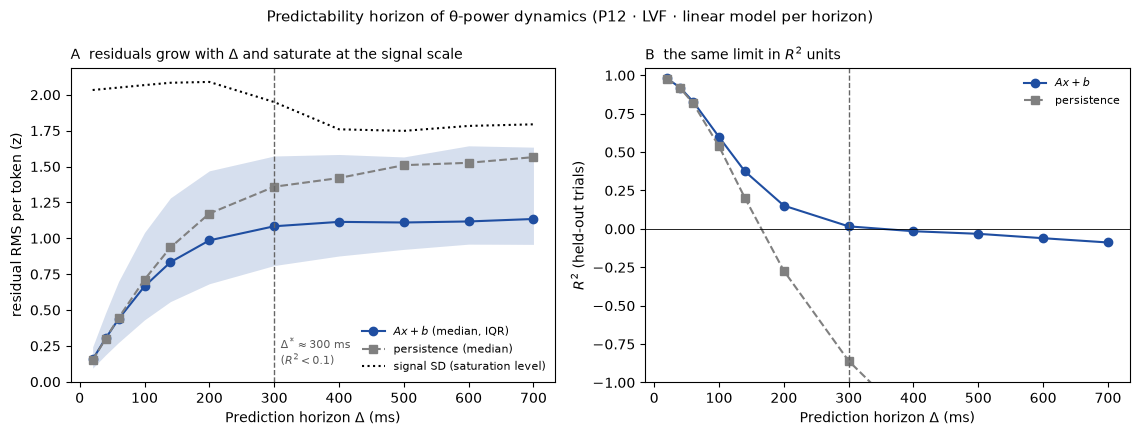

In [36]:
# ---------- Predictability horizon: push Δ until residuals saturate at the signal scale ----------
# Residuals are small because (i) the theta envelope is smooth/autocorrelated and
# (ii) units are signal SDs. Here we extend Δ up to 700 ms to find Δ*, the horizon
# where residual RMS reaches the signal SD and R^2 -> 0 (the meaning of "locally" linear).
h_ext = [20, 40, 60, 100, 140, 200, 300, 400, 500, 600, 700]
rows_h = []
for h_ms in h_ext:
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_r[tr], hs_)
    Xv_, Yv_ = make_pairs(z_r[va], hs_)
    Xi_, Yi_ = make_pairs(z_r[te], hs_)
    A_e, b_e, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    rn_lin = resid_norms(Yi_, ridge_predict(A_e, b_e, Xi_))
    rn_per = resid_norms(Yi_, Xi_)
    sig_sd = float(Yi_.std())                      # test-signal scale at this horizon
    rows_h.append(dict(horizon_ms=h_ms, sig_sd=sig_sd,
                       R2_lin=pop_r2(Yi_, ridge_predict(A_e, b_e, Xi_)),
                       R2_per=pop_r2(Yi_, Xi_),
                       med_lin=float(np.median(rn_lin)), q25_lin=float(np.percentile(rn_lin, 25)),
                       q75_lin=float(np.percentile(rn_lin, 75)),
                       med_per=float(np.median(rn_per))))
hz = pd.DataFrame(rows_h).set_index("horizon_ms")
hz.to_csv(RESULTS_DIR / "predictability_horizon_LVF_theta.csv")

# Δ*: first horizon where linear R^2 drops below 0.1
below = hz[hz.R2_lin < 0.1]
d_star = int(below.index[0]) if len(below) else None

fig, (axE, axQ) = plt.subplots(1, 2, figsize=(11.5, 4.4))
axE.fill_between(hz.index, hz.q25_lin, hz.q75_lin, color=COLOR_LINEAR, alpha=0.18, lw=0)
axE.plot(hz.index, hz.med_lin, "o-", color=COLOR_LINEAR, label="$Ax+b$ (median, IQR)")
axE.plot(hz.index, hz.med_per, "s--", color="gray", label="persistence (median)")
axE.plot(hz.index, hz.sig_sd, ":", color="black", lw=1.5, label="signal SD (saturation level)")
if d_star:
    axE.axvline(d_star, color="0.4", lw=1, ls="--")
    axE.text(d_star + 10, 0.12, f"$\\Delta^*\\approx${d_star} ms\n($R^2<0.1$)", fontsize=8, color="0.35")
axE.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axE.set_ylabel("residual RMS per token (z)")
axE.legend(fontsize=8, frameon=False)
axE.set_title("A  residuals grow with $\\Delta$ and saturate at the signal scale", loc="left", fontsize=10)

axQ.plot(hz.index, hz.R2_lin, "o-", color=COLOR_LINEAR, label="$Ax+b$")
axQ.plot(hz.index, hz.R2_per, "s--", color="gray", label="persistence")
axQ.axhline(0, color="k", lw=0.6)
if d_star:
    axQ.axvline(d_star, color="0.4", lw=1, ls="--")
axQ.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axQ.set_ylabel("$R^2$ (held-out trials)")
axQ.set_ylim(-1.0, 1.05)
axQ.legend(fontsize=8, frameon=False)
axQ.set_title("B  the same limit in $R^2$ units", loc="left", fontsize=10)

fig.suptitle("Predictability horizon of θ-power dynamics (P12 · LVF · linear model per horizon)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"predictability_horizon_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "predictability_horizon_P12_LVF_theta.png")
display(hz.round(3))
plt.show()

**Figure — Predictability horizon Δ\* (P12 · LVF · θ, one linear model per horizon).** Answers "why are the residuals so small, and what happens at larger Δ?". Residuals are small at Δ = 20 ms for two reasons: the θ envelope is smooth and strongly autocorrelated (consecutive 40-ms tokens overlap), and errors are expressed in units of the baseline SD. **A:** median residual RMS (blue, with IQR) grows with horizon and **saturates at ≈ 1.1 z beyond Δ ≈ 300–400 ms** — once errors reach the signal's own scale there is nothing left to predict, and pushing Δ further only reproduces this ceiling. Persistence (gray) keeps getting *worse* past saturation (stale states are anti-correlated with the future), while the linear model degrades gracefully to mean-prediction. **B:** the same limit in $R^2$: linear $R^2$ crosses ~0.1 at **Δ\* ≈ 300 ms** and hovers near 0 afterwards, whereas persistence dives to −1.5. Take-away: the local linearization is meaningful for Δ ≲ 300 ms — this is the quantitative meaning of "locally" — and larger Δ is only useful for establishing this boundary, not for finding more structure. (Consistent with the A-matrix timescales: median stable-mode τ ≈ 180–280 ms at long horizons.)

## Composite-figure panels D–F

Three panels for the summary figure: **D** — does the size of a lead (number of channels in the state) affect the precision of the local linearization? **E** — does the learned residual $g(x)$ still help under the two OOD shifts (conflict, stim-block context)? **F** — does longer temporal context (stacking past tokens) extend the predictability horizon?

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelD_state_size_P12_theta.png


,mean,std
k,,
2,0.193,0.074
4,0.177,0.047
6,0.156,0.016
8,0.148,0.017
10,0.156,0.010
12,0.146,0.006
15,0.152,NaN


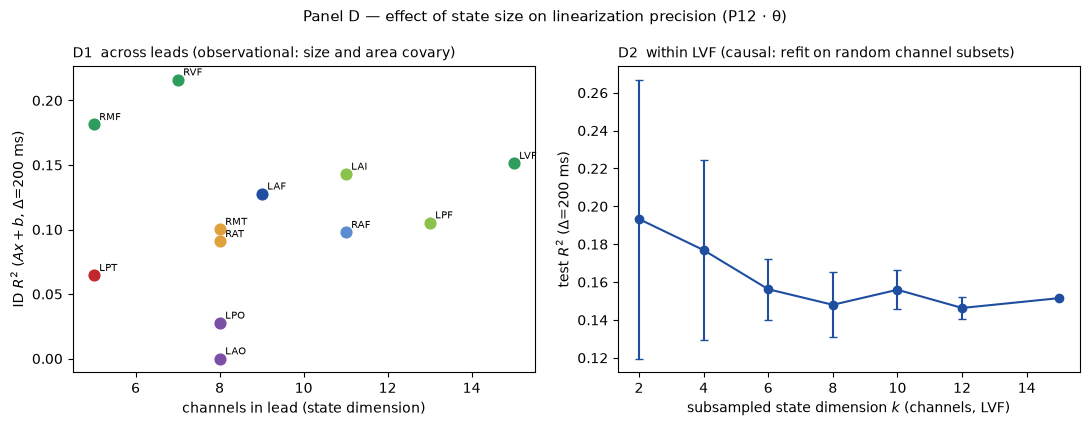

In [37]:
# ---------- Panel D: state size (channels per lead) vs precision of linearization ----------
# Two views: (1) observational — per-lead ID R^2 vs channel count across the montage;
# (2) causal — subsample k channels WITHIN one lead (LVF), refit, test. Δ = 200 ms
# (at 20 ms everything is ~0.98 and size effects are invisible).
h_ms_D = 200
hsD = h_ms_D // TOKEN_STRIDE_MS
obs_D = ood_leads[ood_leads.horizon_ms == h_ms_D]

rng_D = np.random.default_rng(RANDOM_SEED)
n_full = z_r.shape[-1]
ks_D = [2, 4, 6, 8, 10, 12, n_full]
rows_D = []
for k in ks_D:
    for rep in range(1 if k == n_full else 10):
        cols = np.sort(rng_D.choice(n_full, size=k, replace=False))
        zk = z_r[:, :, cols]
        XtD, YtD = make_pairs(zk[tr], hsD)
        XvD, YvD = make_pairs(zk[va], hsD)
        XiD, YiD = make_pairs(zk[te], hsD)
        A_D, b_D, _ = fit_ridge(XtD, YtD, XvD, YvD)
        rows_D.append(dict(k=k, rep=rep, R2=pop_r2(YiD, ridge_predict(A_D, b_D, XiD))))
subs_D = pd.DataFrame(rows_D)
gD = subs_D.groupby("k")["R2"].agg(["mean", "std"])
gD.to_csv(RESULTS_DIR / "panelD_state_size_LVF_theta.csv")

fig, (axO, axC) = plt.subplots(1, 2, figsize=(11, 4.3))
for _, r_ in obs_D.iterrows():
    axO.scatter(r_.n_ch, r_.R2_lin_ID, s=60, color=AREA_COLORS[r_.area], zorder=3)
    axO.annotate(r_.lead, (r_.n_ch, r_.R2_lin_ID), fontsize=7.5, xytext=(4, 3),
                 textcoords="offset points")
axO.set_xlabel("channels in lead (state dimension)")
axO.set_ylabel(f"ID $R^2$ ($Ax+b$, $\\Delta$={h_ms_D} ms)")
axO.set_title("D1  across leads (observational: size and area covary)", loc="left", fontsize=10)

axC.errorbar(gD.index, gD["mean"], yerr=gD["std"], fmt="o-", color=COLOR_LINEAR,
             capsize=3, lw=1.5)
axC.set_xlabel("subsampled state dimension $k$ (channels, LVF)")
axC.set_ylabel(f"test $R^2$ ($\\Delta$={h_ms_D} ms)")
axC.set_title("D2  within LVF (causal: refit on random channel subsets)", loc="left", fontsize=10)
fig.suptitle("Panel D — effect of state size on linearization precision (P12 · θ)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelD_state_size_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelD_state_size_P12_theta.png")
display(gD.round(3))
plt.show()

**Panel D — effect of state size on linearization precision (P12 · θ · Δ = 200 ms).** **D1 (observational):** ID $R^2$ of the per-lead frozen linear model vs. the number of channels in the lead, colored by area. There is no positive size trend — a 7-channel visual lead (RVF, 0.22) beats the 15-channel LVF (0.15), and same-size leads span 0.00–0.14 (LAO vs. LAI); *which area* the lead samples matters far more than *how many channels* it has. **D2 (causal):** refitting on random channel subsets within LVF isolates the size effect: mean test $R^2$ is essentially flat from $k$ = 2 to 15 (≈ 0.15); the only effect of more channels is *reduced variance* across subsets (error bars shrink ~10×). Honest conclusion: at this horizon the precision of the local linearization is set by the area's dynamics, not the state dimension — adding channels buys reliability, not accuracy.

Residual gain ΔR² = R²(Ax+b+g) − R²(Ax+b), frozen models:


conflict         stim-context        
split            ID     OOD           ID     OOD
horizon_ms                                      
20          -0.0013 -0.0025      -0.0006 -0.0023
40          -0.0021 -0.0049      -0.0016 -0.0046
100         -0.0055 -0.0037      -0.0032  0.0044
200         -0.0222 -0.0032       0.0060  0.0348

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelE_residual_gain_ood_P12_LVF_theta.png


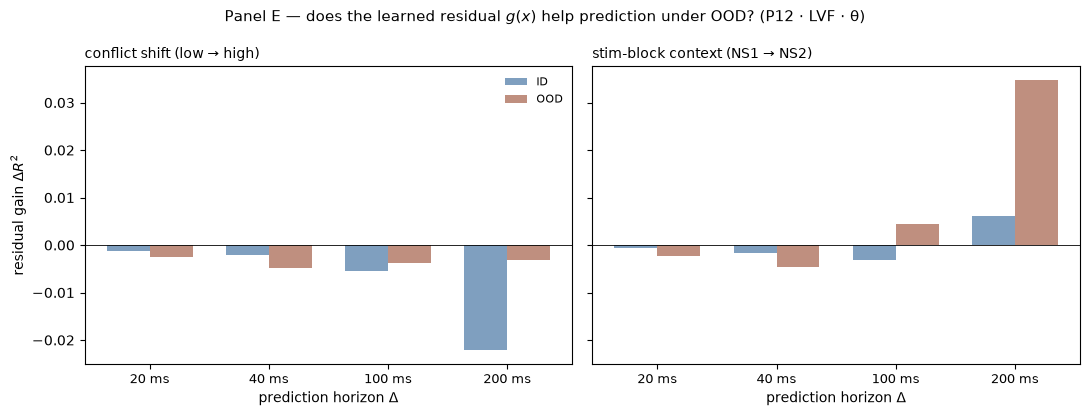

In [38]:
# ---------- Panel E: does the residual model g(x) still help under OOD? ----------
# No refitting needed: `cs` (conflict shift) and `stim_cmp` (stim-block context) already
# hold R^2 for Ax+b and Ax+b+g(x) on ID and OOD with FROZEN models. The residual gain is
#   gain(split) = R^2[Ax+b+g(x)] - R^2[Ax+b].
def resid_gain(tbl):
    return (tbl.loc["Ax+b+g(x)", ["ID", "OOD"]] - tbl.loc["Ax+b", ["ID", "OOD"]]).sort_index()

gain_conf = resid_gain(cs)
gain_stim = resid_gain(stim_cmp)
gains_E = pd.concat({"conflict": gain_conf, "stim-context": gain_stim}, axis=1)
gains_E.to_csv(RESULTS_DIR / "panelE_residual_gain_ood_LVF_theta.csv")
print("Residual gain ΔR² = R²(Ax+b+g) − R²(Ax+b), frozen models:")
display(gains_E.round(4))

fig, axes_E = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax_E, (title_E, gtab) in zip(axes_E, [("conflict shift (low → high)", gain_conf),
                                          ("stim-block context (NS1 → NS2)", gain_stim)]):
    xE = np.arange(len(gtab)); wE = 0.36
    ax_E.bar(xE - wE/2, gtab["ID"], wE, color=COLOR_ID, label="ID")
    ax_E.bar(xE + wE/2, gtab["OOD"], wE, color=COLOR_OOD, label="OOD")
    ax_E.axhline(0, color="k", lw=0.6)
    ax_E.set_xticks(xE, [f"{h} ms" for h in gtab.index], fontsize=9)
    ax_E.set_xlabel("prediction horizon $\\Delta$")
    ax_E.set_title(title_E, loc="left", fontsize=10)
axes_E[0].set_ylabel("residual gain $\\Delta R^2$")
axes_E[0].legend(fontsize=8, frameon=False)
fig.suptitle("Panel E — does the learned residual $g(x)$ help prediction under OOD? (P12 · LVF · θ)",
             fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelE_residual_gain_ood_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelE_residual_gain_ood_P12_LVF_theta.png")
plt.show()

**Panel E — residual gain under OOD (P12 · LVF · θ, frozen models).** Bars show the extra $R^2$ contributed by the learned residual, $\Delta R^2 = R^2[Ax+b+g(x)] - R^2[Ax+b]$, on ID vs. OOD data for the two shift axes. At short horizons (≤ 100 ms) the gain is ≈ 0 everywhere — the dynamics are so close to linear that $g(x)$ has nothing to add. The one clear positive is the **stim-block context shift at Δ = 200 ms: the residual model helps OOD (+0.035) six times more than ID (+0.006)**, recovering about half of the linear model's OOD degradation (−0.07) — i.e., the nonlinear correction learned in no-stim blocks *transfers* and becomes most valuable exactly where the linear map falls short. Under the conflict shift the residual is neutral OOD (−0.003) and mildly overfits ID at 200 ms (−0.022). Honest summary: residuals help prediction in OOD only for the context shift and only at long horizons — a small but real effect in the hypothesized direction.

k_ctx,1,2,4,8
horizon_ms,,,,
20,0.979,0.999,1.000,1.000
40,0.920,0.992,0.999,1.000
100,0.598,0.862,0.965,0.987
200,0.152,0.324,0.625,0.718
300,0.016,0.047,0.128,0.127
400,-0.015,-0.009,-0.073,-0.122
500,-0.032,-0.035,-0.070,-0.120
700,-0.088,-0.113,-0.163,-0.243


Δ* (first horizon with R² < 0.1) per context length: {1: np.int64(300), 2: np.int64(300), 4: np.int64(400), 8: np.int64(400)}
saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelF_context_length_P12_LVF_theta.png


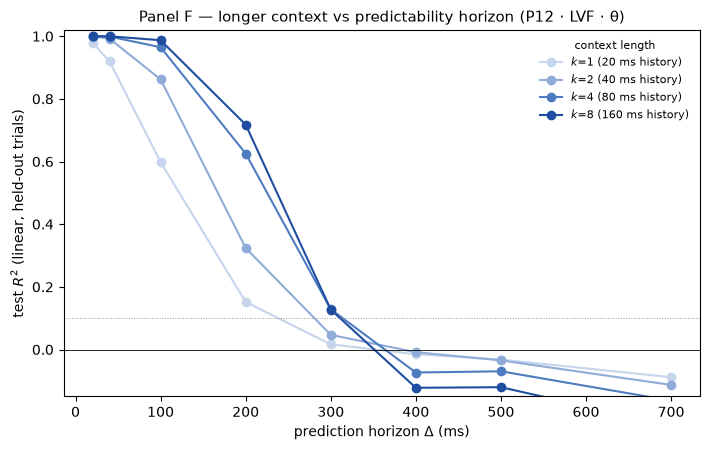

In [39]:
# ---------- Panel F: effect of long context (stack k past tokens as the state) ----------
# Order-k linear model: x_{t+h} = W [x_t; x_{t-1}; ...; x_{t-k+1}] + b.
# k tokens at 20-ms stride ~= 20*k ms of history (tokens themselves are 40-ms windows).
def make_pairs_ctx(z, h_steps, k_ctx):
    """Context-stacked pairs. X: (pairs, ch*k_ctx) with most recent token first."""
    T = z.shape[1]
    Xs = [z[:, k_ctx - 1 - j:T - h_steps - j, :] for j in range(k_ctx)]   # j=0 most recent
    X = np.concatenate(Xs, axis=-1).reshape(-1, z.shape[-1] * k_ctx)
    Y = z[:, k_ctx - 1 + h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y

ks_F = [1, 2, 4, 8]                     # 20 / 40 / 80 / 160 ms of history
h_F = [20, 40, 100, 200, 300, 400, 500, 700]
rows_F = []
for k_ctx in ks_F:
    for h_ms in h_F:
        hsF = h_ms // TOKEN_STRIDE_MS
        XtF, YtF = make_pairs_ctx(z_r[tr], hsF, k_ctx)
        XvF, YvF = make_pairs_ctx(z_r[va], hsF, k_ctx)
        XiF, YiF = make_pairs_ctx(z_r[te], hsF, k_ctx)
        A_F, b_F, _ = fit_ridge(XtF, YtF, XvF, YvF)
        rows_F.append(dict(k_ctx=k_ctx, horizon_ms=h_ms,
                           R2=pop_r2(YiF, ridge_predict(A_F, b_F, XiF))))
ctx_F = pd.DataFrame(rows_F)
ctx_F.to_csv(RESULTS_DIR / "panelF_context_length_LVF_theta.csv", index=False)
pivot_F = ctx_F.pivot(index="horizon_ms", columns="k_ctx", values="R2")
display(pivot_F.round(3))

# Δ* per context length (first horizon with R^2 < 0.1)
dstar_F = {k: (pivot_F.index[pivot_F[k] < 0.1][0] if (pivot_F[k] < 0.1).any() else np.nan)
           for k in ks_F}
print("Δ* (first horizon with R² < 0.1) per context length:", dstar_F)

fig, axF = plt.subplots(figsize=(7.2, 4.6))
shades_F = ["#c6d4ec", "#8fabd8", "#4f7cc0", COLOR_LINEAR]
for k_ctx, colF in zip(ks_F, shades_F):
    axF.plot(pivot_F.index, pivot_F[k_ctx], "o-", color=colF,
             label=f"$k$={k_ctx} ({20*k_ctx} ms history)")
axF.axhline(0, color="k", lw=0.6)
axF.axhline(0.1, color="0.6", lw=0.7, ls=":")
axF.set_xlabel("prediction horizon $\\Delta$ (ms)")
axF.set_ylabel("test $R^2$ (linear, held-out trials)")
axF.set_ylim(-0.15, 1.02)
axF.legend(fontsize=8, frameon=False, title="context length", title_fontsize=8)
axF.set_title("Panel F — longer context vs predictability horizon (P12 · LVF · θ)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelF_context_length_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelF_context_length_P12_LVF_theta.png")
plt.show()

**Panel F — effect of long context (P12 · LVF · θ, order-$k$ linear models).** The state is extended to the last $k$ tokens (20–160 ms of history) and a linear map is refit per (k, Δ). Longer context helps dramatically *inside* the predictability horizon: at Δ = 200 ms, $R^2$ rises from 0.15 ($k$=1) to 0.32 ($k$=2), 0.63 ($k$=4) and **0.72 ($k$=8)** — a short history of the trajectory (velocity/curvature of the θ envelope) carries far more predictive information than the instantaneous state alone. But context only *nudges* the horizon itself: Δ\* moves from 300 ms ($k$=1–2) to 400 ms ($k$=4–8), and beyond the horizon extra context actively hurts (at Δ = 700 ms, $R^2$ drops to −0.24 for $k$=8 vs. −0.09 for $k$=1 — more parameters fitting unforecastable structure). Interpretation: within ~300–400 ms the system is close to a *linear* higher-order Markov process; past that, the barrier is not model capacity but genuine loss of predictable structure — the same wall found in the predictability-horizon figure.

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelD_state_size_resid_P12_theta.png


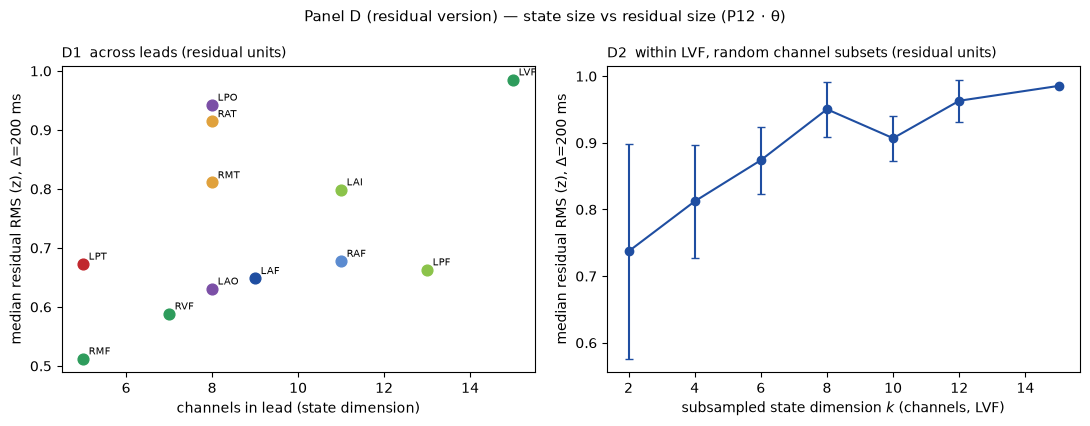

In [40]:
# ---------- Panels D–F, version 2: residual RMS (z) instead of R^2 ----------
# Same analyses; the metric is now the median per-token residual RMS across channels
# (resid_norms), in units of baseline SDs. Lower = better.
h_ms_D = 200; hsD = h_ms_D // TOKEN_STRIDE_MS

# ---- D-v2.1: per-lead median residual RMS (ID, Δ=200 ms; same channel sets as D1) ----
rows_D1r = []
for lead_ in sorted(set(lead_clean)):
    cols_ns2 = np.flatnonzero((lead_clean == lead_) & matched)
    if len(cols_ns2) < MIN_CH:
        continue
    mu_l = baseline[tr][:, cols_ns2].mean(axis=0)
    sd_l = baseline[tr][:, cols_ns2].std(axis=0) + 1e-12
    z_id = (tokens[:, :, cols_ns2] - mu_l) / sd_l
    Xt_, Yt_ = make_pairs(z_id[tr], hsD)
    Xv_, Yv_ = make_pairs(z_id[va], hsD)
    Xi_, Yi_ = make_pairs(z_id[te], hsD)
    A_, b_, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    rows_D1r.append(dict(lead=lead_, area=lead_area[lead_], n_ch=len(cols_ns2),
                         med_resid=float(np.median(resid_norms(Yi_, ridge_predict(A_, b_, Xi_))))))
d1r = pd.DataFrame(rows_D1r)

# ---- D-v2.2: channel subsampling within LVF, median residual RMS ----
rng_D2 = np.random.default_rng(RANDOM_SEED)
rows_D2r = []
for k in ks_D:
    for rep in range(1 if k == n_full else 10):
        cols = np.sort(rng_D2.choice(n_full, size=k, replace=False))
        zk = z_r[:, :, cols]
        XtD, YtD = make_pairs(zk[tr], hsD)
        XvD, YvD = make_pairs(zk[va], hsD)
        XiD, YiD = make_pairs(zk[te], hsD)
        A_D2, b_D2, _ = fit_ridge(XtD, YtD, XvD, YvD)
        rows_D2r.append(dict(k=k, med_resid=float(np.median(resid_norms(YiD, ridge_predict(A_D2, b_D2, XiD))))))
gD2 = pd.DataFrame(rows_D2r).groupby("k")["med_resid"].agg(["mean", "std"])
pd.concat([d1r.set_index("lead"), gD2], axis=0).to_csv(RESULTS_DIR / "panelD_state_size_resid_theta.csv")

fig, (axO2, axC2) = plt.subplots(1, 2, figsize=(11, 4.3))
for _, r_ in d1r.iterrows():
    axO2.scatter(r_.n_ch, r_.med_resid, s=60, color=AREA_COLORS[r_.area], zorder=3)
    axO2.annotate(r_.lead, (r_.n_ch, r_.med_resid), fontsize=7.5, xytext=(4, 3),
                  textcoords="offset points")
axO2.set_xlabel("channels in lead (state dimension)")
axO2.set_ylabel(f"median residual RMS (z), $\\Delta$={h_ms_D} ms")
axO2.set_title("D1  across leads (residual units)", loc="left", fontsize=10)
axC2.errorbar(gD2.index, gD2["mean"], yerr=gD2["std"], fmt="o-", color=COLOR_LINEAR, capsize=3, lw=1.5)
axC2.set_xlabel("subsampled state dimension $k$ (channels, LVF)")
axC2.set_ylabel(f"median residual RMS (z), $\\Delta$={h_ms_D} ms")
axC2.set_title("D2  within LVF, random channel subsets (residual units)", loc="left", fontsize=10)
fig.suptitle("Panel D (residual version) — state size vs residual size (P12 · θ)", fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelD_state_size_resid_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelD_state_size_resid_P12_theta.png")
plt.show()

**Panel D (residual version) — state size vs residual size (P12 · θ · Δ = 200 ms).** Same analyses as Panel D but in raw error units: median per-token residual RMS across channels (z = baseline SDs), lower is better. Note the *opposite apparent trend* to the R² version: residual RMS **grows** with state size (D2: 0.74 → 0.99 z from k = 2 to 15; D1: the 15-channel LVF has the largest residuals, 0.98 z). This is not a contradiction — residual RMS is not variance-normalized, so leads/subsets containing higher-variance channels show bigger absolute errors even when the *fraction* of variance explained (R²) is unchanged. Read the two versions together: R² (flat) says linearization quality is size-independent; residual units say the absolute error budget scales with the signal amplitude of the channels included. The shrinking error bars in D2 (±0.16 → ±0.02) repeat the one real size effect: more channels average out subset-to-subset variability.

split                        ID     OOD
axis         horizon_ms                
conflict     20         -0.0002 -0.0076
             40         -0.0006 -0.0036
             100        -0.0236 -0.0057
             200        -0.0328 -0.0130
stim-context 20         -0.0040 -0.0060
             40         -0.0053 -0.0055
             100        -0.0123  0.0103
             200        -0.0160  0.0586

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelE_residual_gain_ood_resid_P12_LVF_theta.png


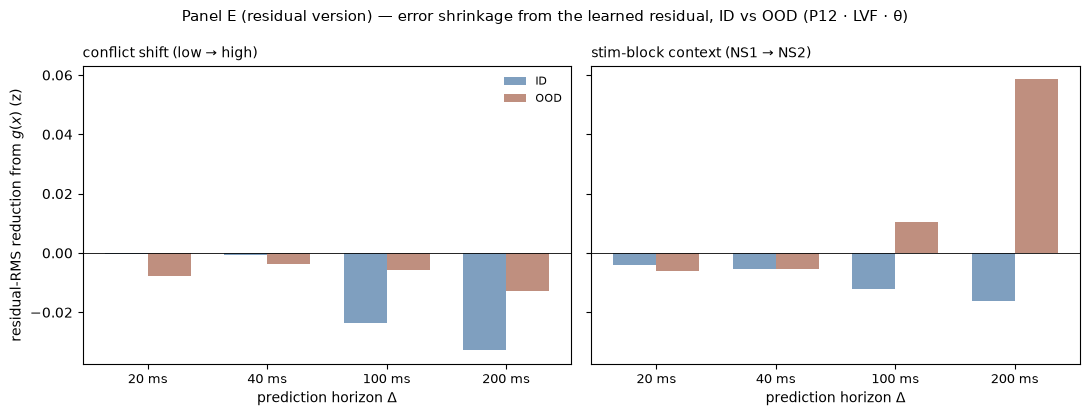

In [41]:
# ---------- Panel E (residual version): residual-RMS reduction from g(x), ID vs OOD ----------
# Metric: median per-token residual RMS of Ax+b minus that of Ax+b+g(x), in z.
# Positive = the learned residual shrinks the errors.
rows_Er = []
# stim-block context: frozen NS1 models
for h_ms, (A_h, b_h, g_h) in sorted(models_at_h.items()):
    hs_ = h_ms // TOKEN_STRIDE_MS
    for split, zz in [("ID", z_r[te]), ("OOD", z_ood)]:
        Xs_, Ys_ = make_pairs(zz, hs_)
        p_l = ridge_predict(A_h, b_h, Xs_)
        m_lin = float(np.median(resid_norms(Ys_, p_l)))
        m_res = float(np.median(resid_norms(Ys_, p_l + mlp_predict(g_h, Xs_))))
        rows_Er.append(dict(axis="stim-context", horizon_ms=h_ms, split=split,
                            med_lin=m_lin, med_res=m_res, reduction=m_lin - m_res))
# conflict shift: frozen low-conflict models (refit per horizon, as in the R^2 version)
for h_ms in [20, 40, 100, 200]:
    hs_ = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_c[tr_lo], hs_)
    Xv_, Yv_ = make_pairs(z_c[va_lo], hs_)
    A_Ec, b_Ec, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_Ec = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_Ec, b_Ec, Xt_),
                            Xv_, Yv_ - ridge_predict(A_Ec, b_Ec, Xv_))
    for split, idxs in [("ID", te_lo), ("OOD", high_trials)]:
        Xs_, Ys_ = make_pairs(z_c[idxs], hs_)
        p_l = ridge_predict(A_Ec, b_Ec, Xs_)
        m_lin = float(np.median(resid_norms(Ys_, p_l)))
        m_res = float(np.median(resid_norms(Ys_, p_l + mlp_predict(g_Ec, Xs_))))
        rows_Er.append(dict(axis="conflict", horizon_ms=h_ms, split=split,
                            med_lin=m_lin, med_res=m_res, reduction=m_lin - m_res))
er = pd.DataFrame(rows_Er)
er.to_csv(RESULTS_DIR / "panelE_residual_gain_ood_resid_LVF_theta.csv", index=False)
display(er.pivot(index=["axis", "horizon_ms"], columns="split", values="reduction").round(4))

fig, axes_E2 = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax_E2, axis_name, ttl in zip(axes_E2, ["conflict", "stim-context"],
                                 ["conflict shift (low → high)", "stim-block context (NS1 → NS2)"]):
    gtab = er[er.axis == axis_name].pivot(index="horizon_ms", columns="split", values="reduction").sort_index()
    xE2 = np.arange(len(gtab)); wE2 = 0.36
    ax_E2.bar(xE2 - wE2/2, gtab["ID"], wE2, color=COLOR_ID, label="ID")
    ax_E2.bar(xE2 + wE2/2, gtab["OOD"], wE2, color=COLOR_OOD, label="OOD")
    ax_E2.axhline(0, color="k", lw=0.6)
    ax_E2.set_xticks(xE2, [f"{h} ms" for h in gtab.index], fontsize=9)
    ax_E2.set_xlabel("prediction horizon $\\Delta$")
    ax_E2.set_title(ttl, loc="left", fontsize=10)
axes_E2[0].set_ylabel("residual-RMS reduction from $g(x)$ (z)")
axes_E2[0].legend(fontsize=8, frameon=False)
fig.suptitle("Panel E (residual version) — error shrinkage from the learned residual, ID vs OOD (P12 · LVF · θ)",
             fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelE_residual_gain_ood_resid_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelE_residual_gain_ood_resid_P12_LVF_theta.png")
plt.show()

**Panel E (residual version) — error shrinkage from $g(x)$, ID vs OOD (P12 · LVF · θ, frozen models).** Bars show how much the learned residual reduces the *median per-token residual RMS* relative to the pure linear model (positive = smaller errors). In raw error units the stim-context result is even sharper than in R²: at Δ = 200 ms, $g(x)$ shrinks the typical OOD error by **0.059 z** (and +0.010 at 100 ms) while *increasing* the typical ID error (−0.016 z). The ID discrepancy with the R² version (where the gain was +0.006) is informative: the MLP improves the ID *sum of squares* (mean, dominated by large-error tokens) but slightly worsens the *median* token — it corrects the tail, not the bulk. Under the conflict shift the residual never reduces the median error in either split (mild ID overfitting grows with horizon, −0.033 z at 200 ms). Conclusion matches the R² version but stronger: the residual's practical value is concentrated in the OOD context shift at long horizons, where it shrinks typical errors by ~6% of a signal SD.

k_ctx,1,2,4,8
horizon_ms,,,,
20,0.156,0.034,0.012,0.007
40,0.303,0.099,0.036,0.019
100,0.665,0.404,0.218,0.145
200,0.985,0.880,0.726,0.642
300,1.084,1.062,1.035,1.051
400,1.114,1.099,1.160,1.199
500,1.110,1.116,1.155,1.192
700,1.134,1.141,1.149,1.185


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/panelF_context_length_resid_P12_LVF_theta.png


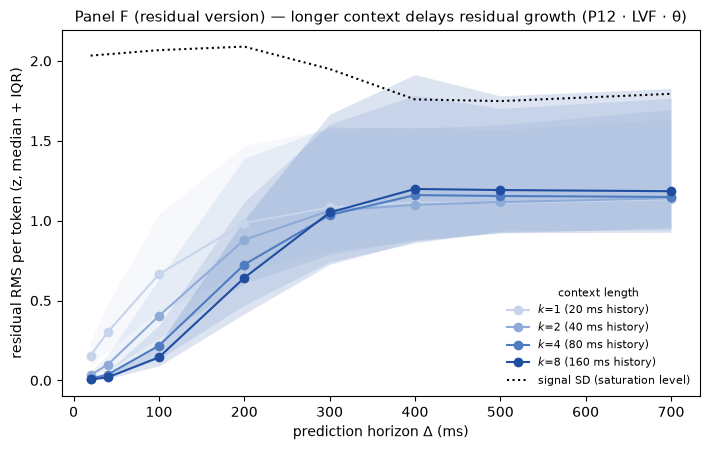

In [42]:
# ---------- Panel F (residual version): context length vs residual RMS across horizons ----------
rows_Fr = []
for k_ctx in ks_F:
    for h_ms in h_F:
        hsF = h_ms // TOKEN_STRIDE_MS
        XtF, YtF = make_pairs_ctx(z_r[tr], hsF, k_ctx)
        XvF, YvF = make_pairs_ctx(z_r[va], hsF, k_ctx)
        XiF, YiF = make_pairs_ctx(z_r[te], hsF, k_ctx)
        A_F2, b_F2, _ = fit_ridge(XtF, YtF, XvF, YvF)
        rn = resid_norms(YiF, ridge_predict(A_F2, b_F2, XiF))
        rows_Fr.append(dict(k_ctx=k_ctx, horizon_ms=h_ms,
                            med=float(np.median(rn)),
                            q25=float(np.percentile(rn, 25)),
                            q75=float(np.percentile(rn, 75))))
ctx_Fr = pd.DataFrame(rows_Fr)
ctx_Fr.to_csv(RESULTS_DIR / "panelF_context_length_resid_LVF_theta.csv", index=False)
pivot_Fr = ctx_Fr.pivot(index="horizon_ms", columns="k_ctx", values="med")
display(pivot_Fr.round(3))

fig, axF2 = plt.subplots(figsize=(7.2, 4.6))
for k_ctx, colF in zip(ks_F, shades_F):
    sub_F = ctx_Fr[ctx_Fr.k_ctx == k_ctx].set_index("horizon_ms").sort_index()
    axF2.fill_between(sub_F.index, sub_F.q25, sub_F.q75, color=colF, alpha=0.15, lw=0)
    axF2.plot(sub_F.index, sub_F.med, "o-", color=colF,
              label=f"$k$={k_ctx} ({20*k_ctx} ms history)")
axF2.plot(hz.loc[h_F].index, hz.loc[h_F, "sig_sd"], ":", color="black", lw=1.5,
          label="signal SD (saturation level)")
axF2.set_xlabel("prediction horizon $\\Delta$ (ms)")
axF2.set_ylabel("residual RMS per token (z, median + IQR)")
axF2.legend(fontsize=8, frameon=False, title="context length", title_fontsize=8)
axF2.set_title("Panel F (residual version) — longer context delays residual growth (P12 · LVF · θ)",
               fontsize=11)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"panelF_context_length_resid_P12_LVF_theta.{ext}", dpi=200, bbox_inches="tight")
print("saved ->", FIG_DIR / "panelF_context_length_resid_P12_LVF_theta.png")
plt.show()

**Panel F (residual version) — context length vs residual growth (P12 · LVF · θ).** Median per-token residual RMS (with IQR bands) vs horizon, one curve per context length $k$; dotted black = signal SD (saturation level). Longer context slashes errors *inside* the horizon: at Δ = 20 ms the median residual drops from 0.156 z ($k$=1) to **0.007 z** ($k$=8) — a 20× reduction, since 160 ms of history nearly determines the next overlapping token — and at Δ = 200 ms from 0.99 to 0.64 z. But all curves converge onto the same ≈ 1.05–1.1 z plateau at Δ ≈ 300 ms, and beyond it the ordering *inverts* ($k$=8 reaches 1.19 z vs. 1.13 z for $k$=1): once no predictable structure remains, extra parameters add estimation noise. The residual view makes the two regimes of Panel F explicit — context buys accuracy only up to the predictability wall, never through it.

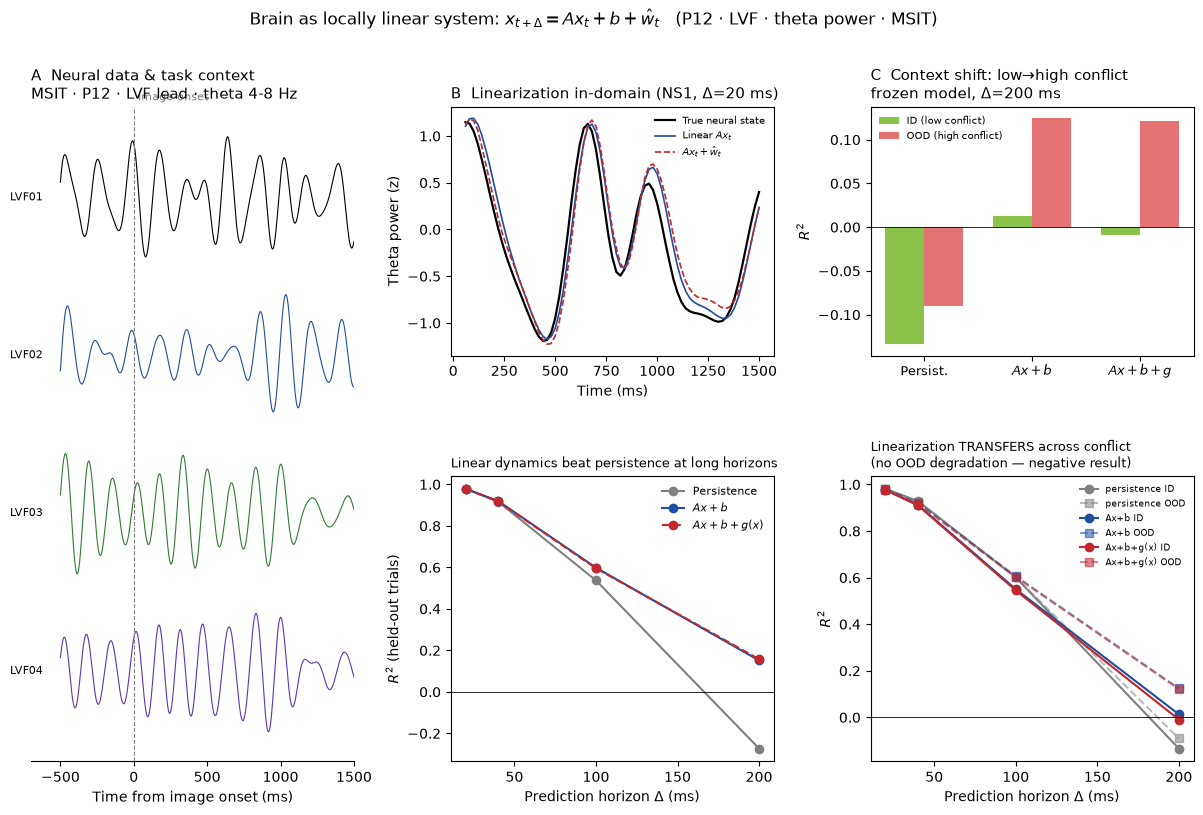

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/main_figure_P12_LVF_theta.png


In [19]:
# ---------- MAIN FIGURE: A data/task context, B linearization in-domain, C context shift ----------
from matplotlib import gridspec
from scipy.signal import butter as _butter, sosfiltfilt as _sosfiltfilt

fig = plt.figure(figsize=(15, 8.5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.15], hspace=0.45, wspace=0.3)

# ===== Panel A: example theta-band traces (4 LVF channels, one NS1 trial) =====
axA = fig.add_subplot(gs[:, 0])
lvf_global = clean_idx[region_mask_in_clean]
demo_trial = int(te[0])
sos_t = _butter(4, BANDS[PRIMARY_BAND], btype="bandpass", fs=sess["fs"], output="sos")
t_ms_full = sess["time"] * 1000.0
show_m = (t_ms_full >= -500) & (t_ms_full <= 1500)
offset = 0.0
trace_colors = ["black", "#1f4ea1", "#2e7d32", "#5e35b1"]
for k, chg in enumerate(lvf_global[:4]):
    sig = _sosfiltfilt(sos_t, sess["data"][demo_trial, chg, :])[show_m]
    sig = sig / (np.abs(sig).max() + 1e-12)
    axA.plot(t_ms_full[show_m], sig + offset, lw=0.8, color=trace_colors[k])
    axA.text(-620, offset, sess["channels"]["pair_name"].iloc[chg].split()[0],
             ha="right", va="center", fontsize=8)
    offset -= 2.6
axA.axvline(0, color="gray", ls="--", lw=0.8)
axA.text(30, 1.6, "image onset", fontsize=8, color="gray")
axA.set_xlim(-700, 1500); axA.set_yticks([])
axA.set_xlabel("Time from image onset (ms)")
axA.set_title("A  Neural data & task context\nMSIT · P12 · %s lead · theta 4-8 Hz" % POC_LEAD,
              loc="left", fontsize=11)
for s in ("left", "right", "top"):
    axA.spines[s].set_visible(False)

# ===== Panel B (top): example one-step prediction, Δ=20 ms =====
axB1 = fig.add_subplot(gs[0, 1])
hs1 = 1
Xd, Yd = z_r[demo_trial, :-hs1, :], z_r[demo_trial, hs1:, :]
A20, b20, g20 = models_at_h[20]
pl = ridge_predict(A20, b20, Xd)
pr = pl + mlp_predict(g20, Xd)
ch_show = 0
tp = token_t[hs1:]
axB1.plot(tp, Yd[:, ch_show], color="black", lw=1.6, label="True neural state")
axB1.plot(tp, pl[:, ch_show], color="#1f4ea1", lw=1.2, label=r"Linear $Ax_t$")
axB1.plot(tp, pr[:, ch_show], color="#c1272d", lw=1.2, ls="--", label=r"$Ax_t+\hat{w}_t$")
axB1.set_xlabel("Time (ms)"); axB1.set_ylabel("Theta power (z)")
axB1.legend(fontsize=7, loc="upper right", frameon=False)
axB1.set_title("B  Linearization in-domain (NS1, $\\Delta$=20 ms)", loc="left", fontsize=11)

# ===== Panel B (bottom): horizon curves, ID =====
axB2 = fig.add_subplot(gs[1, 1])
piv = poc_sweep.pivot(index="horizon_ms", columns="model", values="R2")
axB2.plot(piv.index, piv["persistence"], "o-", color="gray", label="Persistence")
axB2.plot(piv.index, piv["Ax+b"], "o-", color="#1f4ea1", label=r"$Ax+b$")
axB2.plot(piv.index, piv["Ax+b+g(x)"], "o--", color="#c1272d", label=r"$Ax+b+g(x)$")
axB2.axhline(0, color="k", lw=0.6)
axB2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axB2.set_ylabel("$R^2$ (held-out trials)")
axB2.legend(fontsize=8, frameon=False)
axB2.set_title("Linear dynamics beat persistence at long horizons", fontsize=9, loc="left")

# ===== Panel C (top): conflict-shift bars at Δ=200 ms =====
axC1 = fig.add_subplot(gs[0, 2])
h_show = 200
sub = cs.reset_index()
sub = sub[sub["horizon_ms"] == h_show].set_index("model").reindex(["persistence", "Ax+b", "Ax+b+g(x)"])
x = np.arange(len(sub)); w = 0.36
axC1.bar(x - w/2, sub["ID"], w, color="#8bc34a", label="ID (low conflict)")
axC1.bar(x + w/2, sub["OOD"], w, color="#e57373", label="OOD (high conflict)")
axC1.axhline(0, color="k", lw=0.6)
axC1.set_xticks(x); axC1.set_xticklabels(["Persist.", "$Ax+b$", "$Ax+b+g$"], fontsize=9)
axC1.set_ylabel("$R^2$")
axC1.legend(fontsize=7, frameon=False)
axC1.set_title(f"C  Context shift: low→high conflict\nfrozen model, $\\Delta$={h_show} ms", loc="left", fontsize=11)

# ===== Panel C (bottom): ID vs OOD horizon curves for Ax+b =====
axC2 = fig.add_subplot(gs[1, 2])
for model, colr in [("persistence", "gray"), ("Ax+b", "#1f4ea1"), ("Ax+b+g(x)", "#c1272d")]:
    mrows = cs.loc[model]
    axC2.plot(mrows.index, mrows["ID"], "o-", color=colr, label=f"{model} ID")
    axC2.plot(mrows.index, mrows["OOD"], "s--", color=colr, alpha=0.55, label=f"{model} OOD")
axC2.axhline(0, color="k", lw=0.6)
axC2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axC2.set_ylabel("$R^2$")
axC2.legend(fontsize=6.5, frameon=False, ncol=1)
axC2.set_title("Linearization TRANSFERS across conflict\n(no OOD degradation — negative result)",
               fontsize=9, loc="left")

fig.suptitle("Brain as locally linear system: $x_{t+\\Delta} = Ax_t + b + \\hat{w}_t$   "
             "(P12 · LVF · theta power · MSIT)", fontsize=12, y=0.995)
out = FIG_DIR / "main_figure_P12_LVF_theta.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved ->", out)


**Figure — Main summary, θ-power state (P12 · LVF · MSIT).** **A:** example theta-band traces from four LVF channels around image onset — the raw material of the state vector. **B (top):** one-step prediction (Δ = 20 ms) on a held-out trial; both $Ax_t$ (blue) and $Ax_t+\hat{w}_t$ (red) overlay the true state (black). **B (bottom):** $R^2$ vs horizon on held-out trials — the linear map beats persistence increasingly with horizon, and the residual MLP adds little, i.e., dynamics are locally linear with a small nonlinearity budget. **C:** conflict context shift — models fit on low-conflict trials, applied frozen to high-conflict trials. Bars (Δ = 200 ms) and horizon curves show **no OOD degradation**: the same local linear dynamics govern low- and high-conflict processing (an honest negative — cognitive conflict does not change θ-power dynamics in this lead, unlike the stim-block context shift shown later).

In [20]:
# ---------- RAW-SIGNAL VERSION: state = broadband LFP voltage (no band filtering) ----------
# Same tokenization (causal 40-ms mean, 20-ms stride), same models, same splits.
# Normalization: z-score per channel using TRAINING-trial baseline (-500..0 ms) stats.

# 1) tokens from raw voltage on the same LVF clean channels
raw = sess["data"][:, clean_idx, :][:, region_mask_in_clean, :]     # (trials, ch, samples)
tok_raw, base_raw_mean, _ = tokenize(raw, sess["time"])             # baseline mean unused for sd
t_ms_full = sess["time"] * 1000.0
base_m = (t_ms_full >= EPOCH_MS[0]) & (t_ms_full < 0)
base_sd_trial = raw[:, :, base_m].std(axis=-1)                      # (trials, ch)

mu_raw = tok_raw[tr][:, :, :].reshape(-1, tok_raw.shape[-1]).mean(axis=0)
sd_raw = base_sd_trial[tr].mean(axis=0) + 1e-12                     # train baseline sd
z_raw = (tok_raw - mu_raw[None, None, :]) / sd_raw[None, None, :]

# 2) fit across horizons (same 60/20/20 trial split tr/va/te as theta analysis)
rows_raw = []
models_raw = {}
for h_ms in [20, 40, 100, 200]:
    hsr = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_raw[tr], hsr)
    Xv_, Yv_ = make_pairs(z_raw[va], hsr)
    Xe_, Ye_ = make_pairs(z_raw[te], hsr)
    A_r, b_r, lam_r = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_r = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_r, b_r, Xt_),
                           Xv_, Yv_ - ridge_predict(A_r, b_r, Xv_))
    models_raw[h_ms] = (A_r, b_r, g_r)
    p_l = ridge_predict(A_r, b_r, Xe_)
    p_r = p_l + mlp_predict(g_r, Xe_)
    for nm, pp in [("persistence", Xe_), ("Ax+b", p_l), ("Ax+b+g(x)", p_r)]:
        rows_raw.append({"horizon_ms": h_ms, "model": nm, "R2": pop_r2(Ye_, pp)})
raw_sweep = pd.DataFrame(rows_raw)
print("RAW signal, ID horizon sweep (R^2):")
display(raw_sweep.pivot(index="horizon_ms", columns="model", values="R2").round(4))

# 3) conflict-shift OOD with raw state (frozen low-conflict model)
mu_raw_lo = tok_raw[tr_lo].reshape(-1, tok_raw.shape[-1]).mean(axis=0)
sd_raw_lo = base_sd_trial[tr_lo].mean(axis=0) + 1e-12
z_raw_c = (tok_raw - mu_raw_lo[None, None, :]) / sd_raw_lo[None, None, :]
rows_raw_c = []
for h_ms in [20, 40, 100, 200]:
    hsr = h_ms // TOKEN_STRIDE_MS
    Xt_, Yt_ = make_pairs(z_raw_c[tr_lo], hsr)
    Xv_, Yv_ = make_pairs(z_raw_c[va_lo], hsr)
    Xi_, Yi_ = make_pairs(z_raw_c[te_lo], hsr)
    Xo_, Yo_ = make_pairs(z_raw_c[high_trials], hsr)
    A_rc, b_rc, _ = fit_ridge(Xt_, Yt_, Xv_, Yv_)
    g_rc = fit_residual_mlp(Xt_, Yt_ - ridge_predict(A_rc, b_rc, Xt_),
                            Xv_, Yv_ - ridge_predict(A_rc, b_rc, Xv_))
    for split, Xs_, Ys_ in [("ID", Xi_, Yi_), ("OOD", Xo_, Yo_)]:
        p_l = ridge_predict(A_rc, b_rc, Xs_)
        rows_raw_c += [{"horizon_ms": h_ms, "split": split, "model": "persistence", "R2": pop_r2(Ys_, Xs_)},
                       {"horizon_ms": h_ms, "split": split, "model": "Ax+b", "R2": pop_r2(Ys_, p_l)},
                       {"horizon_ms": h_ms, "split": split, "model": "Ax+b+g(x)",
                        "R2": pop_r2(Ys_, p_l + mlp_predict(g_rc, Xs_))}]
cs_raw = pd.DataFrame(rows_raw_c).pivot(index=["model", "horizon_ms"], columns="split", values="R2")
cs_raw["delta_R2"] = cs_raw["OOD"] - cs_raw["ID"]
print("\nRAW signal, conflict-shift OOD (frozen low-conflict model, R^2):")
display(cs_raw.round(4))


RAW signal, ID horizon sweep (R^2):


model,Ax+b,Ax+b+g(x),persistence
horizon_ms,,,
20,0.6923,0.6948,0.6053
40,0.3137,0.3197,-0.1692
100,0.1219,0.1230,-1.0847
200,0.0496,0.0586,-0.8183



RAW signal, conflict-shift OOD (frozen low-conflict model, R^2):


split                       ID     OOD  delta_R2
model       horizon_ms                          
Ax+b        20          0.7053  0.6550   -0.0503
            40          0.3232  0.2642   -0.0590
            100         0.0954  0.1258    0.0304
            200         0.0395  0.0528    0.0134
Ax+b+g(x)   20          0.7054  0.6546   -0.0508
            40          0.3233  0.2627   -0.0606
            100         0.0923  0.1239    0.0317
            200         0.0472  0.0506    0.0034
persistence 20          0.6220  0.5545   -0.0675
            40         -0.1360 -0.3263   -0.1904
            100        -1.0657 -1.2365   -0.1708
            200        -0.8687 -0.8115    0.0573

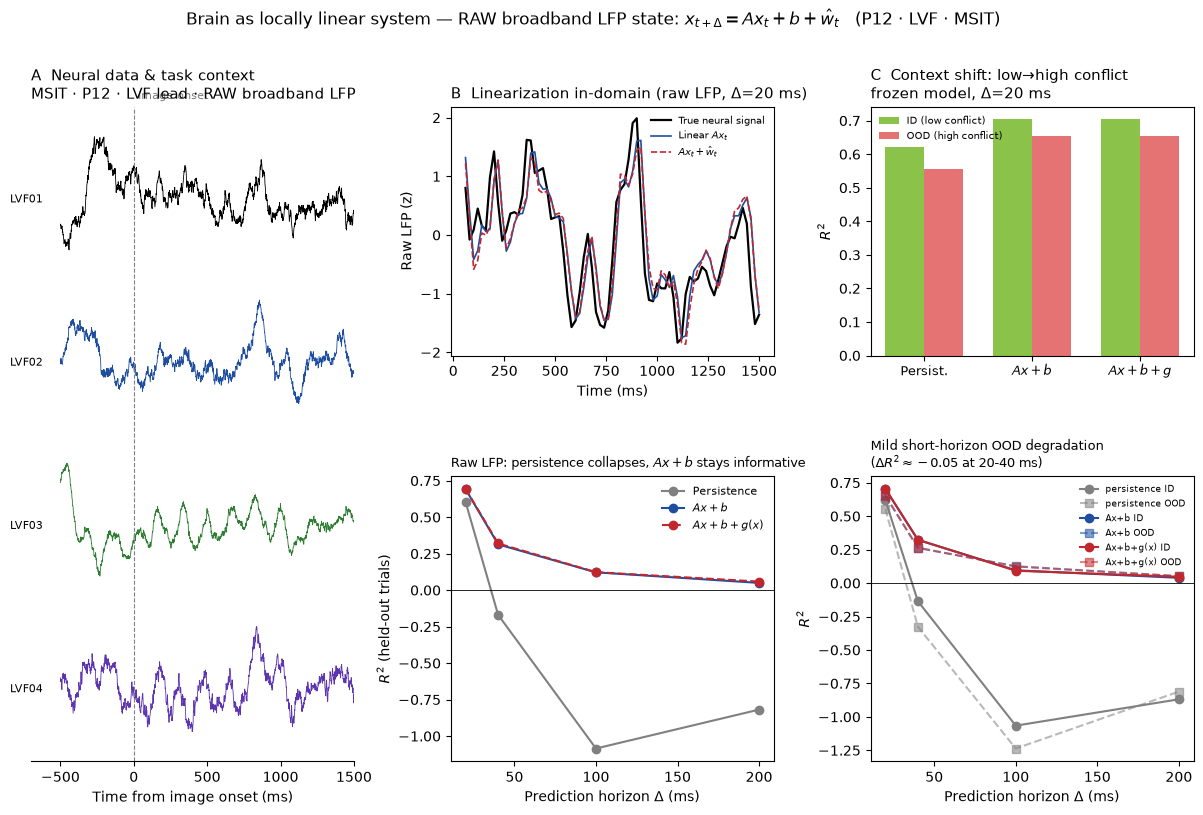

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/main_figure_raw_P12_LVF.png


In [21]:
# ---------- RAW-SIGNAL MAIN FIGURE (mirror of the theta figure) ----------
fig = plt.figure(figsize=(15, 8.5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.15], hspace=0.45, wspace=0.3)

# ===== Panel A: raw broadband traces (4 LVF channels, one held-out trial) =====
axA = fig.add_subplot(gs[:, 0])
show_m = (t_ms_full >= -500) & (t_ms_full <= 1500)
offset = 0.0
for k, chg in enumerate(lvf_global[:4]):
    sig = sess["data"][demo_trial, chg, :][show_m]
    sig = sig / (np.abs(sig).max() + 1e-12)
    axA.plot(t_ms_full[show_m], sig + offset, lw=0.6, color=trace_colors[k])
    axA.text(-620, offset, sess["channels"]["pair_name"].iloc[chg].split()[0],
             ha="right", va="center", fontsize=8)
    offset -= 2.6
axA.axvline(0, color="gray", ls="--", lw=0.8)
axA.text(30, 1.6, "image onset", fontsize=8, color="gray")
axA.set_xlim(-700, 1500); axA.set_yticks([])
axA.set_xlabel("Time from image onset (ms)")
axA.set_title("A  Neural data & task context\nMSIT · P12 · %s lead · RAW broadband LFP" % POC_LEAD,
              loc="left", fontsize=11)
for s in ("left", "right", "top"):
    axA.spines[s].set_visible(False)

# ===== Panel B (top): example one-step prediction on raw state, Δ=20 ms =====
axB1 = fig.add_subplot(gs[0, 1])
hs1 = 1
Xd_r, Yd_r = z_raw[demo_trial, :-hs1, :], z_raw[demo_trial, hs1:, :]
A_r20, b_r20, g_r20 = models_raw[20]
pl_r = ridge_predict(A_r20, b_r20, Xd_r)
pr_r = pl_r + mlp_predict(g_r20, Xd_r)
tp = token_t[hs1:]
axB1.plot(tp, Yd_r[:, 0], color="black", lw=1.6, label="True neural signal")
axB1.plot(tp, pl_r[:, 0], color="#1f4ea1", lw=1.2, label=r"Linear $Ax_t$")
axB1.plot(tp, pr_r[:, 0], color="#c1272d", lw=1.2, ls="--", label=r"$Ax_t+\hat{w}_t$")
axB1.set_xlabel("Time (ms)"); axB1.set_ylabel("Raw LFP (z)")
axB1.legend(fontsize=7, loc="upper right", frameon=False)
axB1.set_title("B  Linearization in-domain (raw LFP, $\\Delta$=20 ms)", loc="left", fontsize=11)

# ===== Panel B (bottom): horizon curves, ID =====
axB2 = fig.add_subplot(gs[1, 1])
piv_r = raw_sweep.pivot(index="horizon_ms", columns="model", values="R2")
axB2.plot(piv_r.index, piv_r["persistence"], "o-", color="gray", label="Persistence")
axB2.plot(piv_r.index, piv_r["Ax+b"], "o-", color="#1f4ea1", label=r"$Ax+b$")
axB2.plot(piv_r.index, piv_r["Ax+b+g(x)"], "o--", color="#c1272d", label=r"$Ax+b+g(x)$")
axB2.axhline(0, color="k", lw=0.6)
axB2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axB2.set_ylabel("$R^2$ (held-out trials)")
axB2.legend(fontsize=8, frameon=False)
axB2.set_title("Raw LFP: persistence collapses, $Ax+b$ stays informative", fontsize=9, loc="left")

# ===== Panel C (top): conflict-shift bars at Δ=20 ms (raw) =====
axC1 = fig.add_subplot(gs[0, 2])
h_show = 20
sub_r = cs_raw.reset_index()
sub_r = sub_r[sub_r["horizon_ms"] == h_show].set_index("model").reindex(["persistence", "Ax+b", "Ax+b+g(x)"])
x = np.arange(len(sub_r)); w = 0.36
axC1.bar(x - w/2, sub_r["ID"], w, color="#8bc34a", label="ID (low conflict)")
axC1.bar(x + w/2, sub_r["OOD"], w, color="#e57373", label="OOD (high conflict)")
axC1.axhline(0, color="k", lw=0.6)
axC1.set_xticks(x); axC1.set_xticklabels(["Persist.", "$Ax+b$", "$Ax+b+g$"], fontsize=9)
axC1.set_ylabel("$R^2$")
axC1.legend(fontsize=7, frameon=False)
axC1.set_title(f"C  Context shift: low→high conflict\nfrozen model, $\\Delta$={h_show} ms", loc="left", fontsize=11)

# ===== Panel C (bottom): ID vs OOD horizon curves (raw) =====
axC2 = fig.add_subplot(gs[1, 2])
for model, colr in [("persistence", "gray"), ("Ax+b", "#1f4ea1"), ("Ax+b+g(x)", "#c1272d")]:
    mrows = cs_raw.loc[model]
    axC2.plot(mrows.index, mrows["ID"], "o-", color=colr, label=f"{model} ID")
    axC2.plot(mrows.index, mrows["OOD"], "s--", color=colr, alpha=0.55, label=f"{model} OOD")
axC2.axhline(0, color="k", lw=0.6)
axC2.set_xlabel("Prediction horizon $\\Delta$ (ms)"); axC2.set_ylabel("$R^2$")
axC2.legend(fontsize=6.5, frameon=False)
axC2.set_title("Mild short-horizon OOD degradation\n($\\Delta R^2 \\approx -0.05$ at 20-40 ms)",
               fontsize=9, loc="left")

fig.suptitle("Brain as locally linear system — RAW broadband LFP state: "
             "$x_{t+\\Delta} = Ax_t + b + \\hat{w}_t$   (P12 · LVF · MSIT)", fontsize=12, y=0.995)
out = FIG_DIR / "main_figure_raw_P12_LVF.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved ->", out)


**Figure — Main summary on the RAW broadband LFP state (P12 · LVF · MSIT).** Same layout as the θ-power figure, but the state vector is the raw (unfiltered, z-scored) LFP — a much harder target, since broadband voltage decorrelates within tens of milliseconds. **A:** raw broadband traces. **B:** persistence collapses almost immediately, yet the linear map $Ax+b$ remains clearly informative at Δ = 20 ms — evidence that the local-linearity result is not an artifact of band-power smoothing. **C:** conflict shift on the raw state shows only a mild short-horizon OOD degradation (ΔR² ≈ −0.05 at 20–40 ms), again broadly consistent with transfer across cognitive context. Take-away: the locally linear description degrades gracefully, not catastrophically, when moving from smooth power envelopes to raw voltage.

## 5b. Where are the electrodes? — anatomy + model schematic

Glass-brain view of all 151 bipolar pairs (MNI midpoint coordinates from `ParcellationValues`), colored by coarse anatomical area, with ictal-onset pairs marked ✕. Right: the same recording drawn as an LLM-style linear token model.

saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/electrode_map_P12.png
         x     y     z   n  n_clean                            area
lead                                                               
LAF  -40.0  13.7  51.0  11        9         dorsolateral prefrontal
LAI  -31.5 -15.6  52.6  11       11                    sensorimotor
LAO  -34.9 -70.5  18.1  15        8               parieto-occipital
LMF  -30.2  -4.0  56.6  13        4  premotor / dorsomedial frontal
LOF  -35.0  21.1  24.5  13        0        ventrolateral prefrontal
LPF  -31.3 -18.8  62.3  13       13                    sensorimotor
LPO  -19.1 -93.4   7.3   9        8               parieto-occipital
LPT  -39.9 -52.4   0.3   8        5              posterior temporal
LVF  -24.6  -7.9  44.1  15       15  premotor / dorsomedial frontal
RAF   23.5  33.7  35.3  11       11        ventrolateral prefrontal
RAT   41.3   4.6   2.8   8        8         temporal / peri-insular
RMF   13.7  -6.

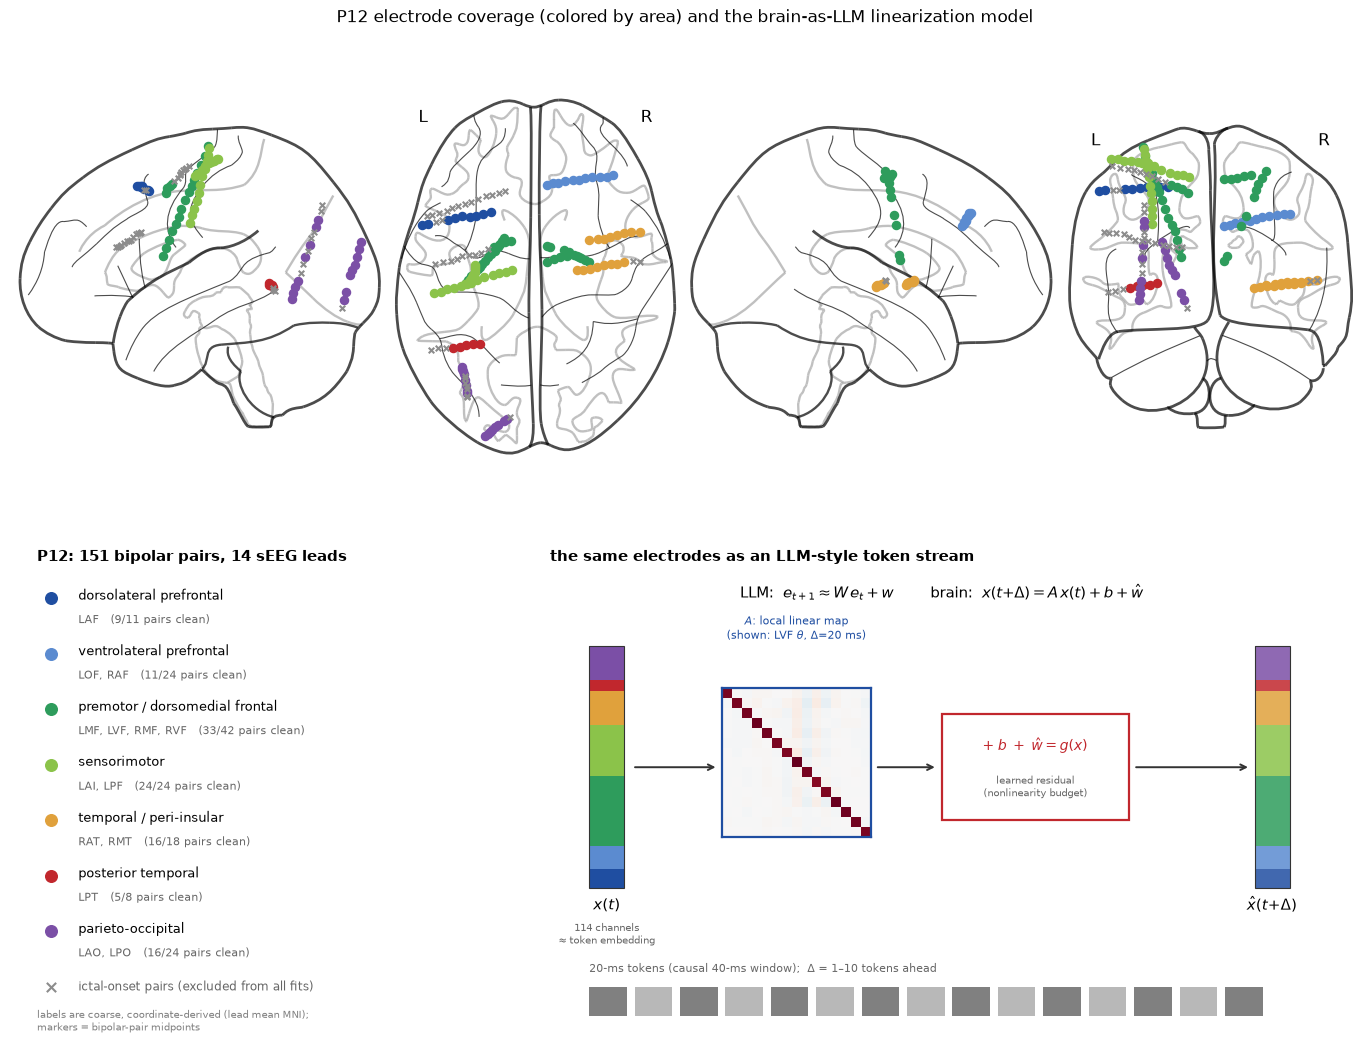

In [11]:
# --- Electrode anatomy (glass brain) + "brain as LLM" model schematic ---
from nilearn import plotting as niplot
from matplotlib.patches import Rectangle

chdf = sess["channels"].copy()
coords = chdf[["parc4", "parc5", "parc6"]].to_numpy(float)  # bipolar-pair midpoints, MNI mm
valid = np.isfinite(coords).all(axis=1)

def coarse_area(x, y, z):
    """Coarse, coordinate-derived anatomical label (from each lead's mean MNI position)."""
    if y <= -60:            return "parieto-occipital"
    if y <= -35 and z < 25: return "posterior temporal"
    if z < 20:              return "temporal / peri-insular"
    if z >= 40 and y >= 10: return "dorsolateral prefrontal"
    if y >= 10:             return "ventrolateral prefrontal"
    if y <= -12:            return "sensorimotor"
    return "premotor / dorsomedial frontal"

lead_stats = chdf[valid].groupby("lead").agg(
    x=("parc4", "mean"), y=("parc5", "mean"), z=("parc6", "mean"),
    n=("pair_name", "size"), n_clean=("ictal", lambda s: int((~s).sum())))
lead_area = {ld: coarse_area(r.x, r.y, r.z) for ld, r in lead_stats.iterrows()}
chdf["area"] = chdf["lead"].map(lead_area)

AREA_ORDER = ["dorsolateral prefrontal", "ventrolateral prefrontal", "premotor / dorsomedial frontal",
              "sensorimotor", "temporal / peri-insular", "posterior temporal", "parieto-occipital"]
AREA_COLORS = dict(zip(AREA_ORDER, ["#1f4ea1", "#5b8bd0", "#2e9c5c", "#8bc34a", "#e0a13c", "#c1272d", "#7b4fa6"]))

fig = plt.figure(figsize=(13.5, 10.5))
disp = niplot.plot_glass_brain(None, display_mode="lzry", figure=fig, axes=(0.0, 0.52, 1.0, 0.44))
for area in AREA_ORDER:
    m = (valid & (~chdf["ictal"]) & (chdf["area"] == area)).to_numpy()
    if m.any():
        disp.add_markers(coords[m], marker_color=AREA_COLORS[area], marker_size=34)
m_ict = (valid & chdf["ictal"]).to_numpy()
disp.add_markers(coords[m_ict], marker_color="0.55", marker_size=16, marker="x")

# ---- legend (bottom left) ----
ax_leg = fig.add_axes([0.02, 0.02, 0.34, 0.46]); ax_leg.axis("off")
ax_leg.text(0.0, 1.00, "P12: 151 bipolar pairs, 14 sEEG leads", fontsize=10.5, weight="bold",
            transform=ax_leg.transAxes, va="top")
yy = 0.90
for area in AREA_ORDER:
    lds = sorted(ld for ld, a in lead_area.items() if a == area)
    if not lds:
        continue
    n_cl = int(lead_stats.loc[lds, "n_clean"].sum()); n_tot = int(lead_stats.loc[lds, "n"].sum())
    ax_leg.scatter([0.03], [yy], s=70, color=AREA_COLORS[area], transform=ax_leg.transAxes, clip_on=False)
    ax_leg.text(0.09, yy + 0.005, area, fontsize=9.5, va="center", transform=ax_leg.transAxes)
    ax_leg.text(0.09, yy - 0.045, f"{', '.join(lds)}   ({n_cl}/{n_tot} pairs clean)",
                fontsize=8, color="0.4", va="center", transform=ax_leg.transAxes)
    yy -= 0.115
ax_leg.scatter([0.03], [yy], s=45, color="0.55", marker="x", transform=ax_leg.transAxes)
ax_leg.text(0.09, yy, "ictal-onset pairs (excluded from all fits)", fontsize=8.5, color="0.4",
            va="center", transform=ax_leg.transAxes)
ax_leg.text(0.0, yy - 0.09, "labels are coarse, coordinate-derived (lead mean MNI);\nmarkers = bipolar-pair midpoints",
            fontsize=7.5, color="0.5", transform=ax_leg.transAxes)

# ---- "brain as LLM" schematic (bottom right) ----
ax_s = fig.add_axes([0.40, 0.02, 0.58, 0.46]); ax_s.axis("off")
ax_s.set_xlim(0, 1); ax_s.set_ylim(0, 1)
ax_s.text(0.0, 1.00, "the same electrodes as an LLM-style token stream", fontsize=10.5, weight="bold", va="top")
ax_s.text(0.5, 0.90, "LLM:  $e_{t+1} \\approx W\\,e_t + w$        brain:  $x(t{+}\\Delta) = A\\,x(t) + b + \\hat{w}$",
          ha="center", fontsize=10.5)

clean_ch = chdf[~chdf["ictal"]].copy()
clean_ch["_o"] = clean_ch["area"].map({a: i for i, a in enumerate(AREA_ORDER)})
clean_ch = clean_ch.sort_values("_o")
n_cells = len(clean_ch)

def draw_vec(x0, alpha=1.0):
    h = 0.50 / n_cells
    for i, area in enumerate(clean_ch["area"]):
        ax_s.add_patch(Rectangle((x0, 0.30 + i * h), 0.045, h, color=AREA_COLORS[area], alpha=alpha, lw=0))
    ax_s.add_patch(Rectangle((x0, 0.30), 0.045, 0.50, fill=False, ec="0.2", lw=0.8))

draw_vec(0.05); draw_vec(0.90, alpha=0.85)
ax_s.text(0.0725, 0.255, "$x(t)$", ha="center", fontsize=11)
ax_s.text(0.9225, 0.255, "$\\hat{x}(t{+}\\Delta)$", ha="center", fontsize=11)
ax_s.text(0.0725, 0.185, "114 channels\n≈ token embedding", ha="center", fontsize=7.5, color="0.4")

axA = ax_s.inset_axes([0.22, 0.36, 0.19, 0.40])
vA = np.abs(A).max()
axA.imshow(A, cmap="RdBu_r", vmin=-vA, vmax=vA)
axA.set_xticks([]); axA.set_yticks([])
for sp in axA.spines.values():
    sp.set_color(COLOR_LINEAR); sp.set_linewidth(1.6)
ax_s.text(0.315, 0.815, "$A$: local linear map\n(shown: LVF $\\theta$, $\\Delta$=20 ms)",
          ha="center", fontsize=8, color=COLOR_LINEAR)

ax_s.add_patch(Rectangle((0.50, 0.44), 0.24, 0.22, fill=False, ec=COLOR_RESIDUAL, lw=1.6))
ax_s.text(0.62, 0.585, "$+\\;b\\;+\\;\\hat{w}=g(x)$", ha="center", fontsize=10, color=COLOR_RESIDUAL)
ax_s.text(0.62, 0.49, "learned residual\n(nonlinearity budget)", ha="center", fontsize=7.5, color="0.4")

for x0, x1 in [(0.105, 0.215), (0.415, 0.495), (0.745, 0.895)]:
    ax_s.annotate("", xy=(x1, 0.55), xytext=(x0, 0.55),
                  arrowprops=dict(arrowstyle="->", lw=1.4, color="0.2"))

for i in range(15):
    ax_s.add_patch(Rectangle((0.05 + i * 0.058, 0.035), 0.048, 0.06,
                             color="0.72" if i % 2 else "0.5", lw=0))
ax_s.text(0.05, 0.125, "20-ms tokens (causal 40-ms window);  $\\Delta$ = 1–10 tokens ahead",
          fontsize=8, color="0.4")

fig.suptitle("P12 electrode coverage (colored by area) and the brain-as-LLM linearization model",
             fontsize=12, y=0.995)
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"electrode_map_P12.{ext}", dpi=200, bbox_inches="tight")
print(f"saved -> {FIG_DIR / 'electrode_map_P12.png'}")
print(lead_stats.round(1).assign(area=[lead_area[ld] for ld in lead_stats.index]).to_string())
plt.show()

**Figure — Electrode coverage and the brain-as-LLM model schematic (P12).** **Top:** glass-brain projections of all 151 bipolar-pair midpoints (MNI coordinates), colored by a coarse, coordinate-derived anatomical area of each sEEG lead (7 areas spanning dorsolateral/ventrolateral prefrontal, premotor, sensorimotor, temporal, posterior temporal, parieto-occipital); gray × = 37 ictal-onset pairs excluded from all fits, leaving 114 clean channels. Labels are approximate (lead-mean MNI position), not clinical parcellations. **Bottom right:** the analogy driving the analysis — the 114-channel state vector $x(t)$ plays the role of an LLM token embedding, the fitted $A$ (shown: LVF θ, Δ = 20 ms) is the local linear map between consecutive "tokens" (20-ms bins, causal 40-ms windows), and the learned residual $g(x)$ is the explicit nonlinearity budget: $x(t+\Delta) = Ax(t) + b + \hat{w}$.

## 5c. Robustness: does the conclusion hold over *enough data*?

The POC above used one lead (LVF), one session (NoStim2), and a short window (0–1.5 s).
Here we re-run the identical pipeline on **both no-stim sessions combined**, an **extended 0–3.5 s token window**, and **every lead with ≥ 5 clean channels** — same whole-trial 60/20/20 split, same train-only λ / normalization rules.

In [17]:
# --- Robustness: every lead x BOTH no-stim sessions x extended 0-3.5 s window ---
# Addresses "only a short interval of the data": ~2.6x more trials (NS1+NS2),
# 2.3x longer token window, and all leads with >=5 clean channels (not just LVF).
NS1_PATH = HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim1.mat"
if (CACHE_DIR / "P12_NoStim1.npz").exists():
    sess1 = load_cached("P12_NoStim1")
else:
    sess1 = load_session(NS1_PATH)
    cache_session(sess1, "P12_NoStim1")
sess1["channels"]["lead"] = sess1["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")

# Montages differ slightly (NS1: 145 pairs / 45 ictal, NS2: 151 / 37).
# Keep only pairs present in BOTH sessions and clean in BOTH sessions.
c1, c2 = sess1["channels"], sess["channels"]
ict1 = dict(zip(c1["pair_name"], c1["ictal"]))
keep = [p for p, ict in zip(c2["pair_name"], c2["ictal"])
        if p in ict1 and not ict and not ict1[p]]
idx1 = pd.Index(c1["pair_name"]).get_indexer(keep)
idx2 = pd.Index(c2["pair_name"]).get_indexer(keep)
lead_of_keep = c2.set_index("pair_name").loc[keep, "lead"].to_numpy()
print(f"NoStim1: {sess1['data'].shape[0]} trials | NoStim2: {sess['data'].shape[0]} trials | "
      f"pairs clean in both sessions: {len(keep)}")

T_END_MS = 3500  # image onset .. +3.5 s (median RT ~1-1.5 s; trials recorded to +4 s)

def tokenize_upto(power, time, t_end_ms):
    """Same causal tokens as tokenize(), but out to t_end_ms."""
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, t_end_ms + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = [power[:, :, (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)].mean(axis=-1) for t in token_t]
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    return np.stack(toks, axis=1), power[:, :, base_m].mean(axis=-1), token_t

d1 = sess1["data"][:, idx1, :]
good1 = ~np.isnan(d1).any(axis=(1, 2))  # NS1 contains aborted trial(s) padded with NaN
if (~good1).any():
    print(f"dropping {(~good1).sum()} NS1 trial(s) with NaN data")
pw1 = band_power(d1[good1], sess1["fs"], PRIMARY_BAND)
tok1, base1, token_t_ext = tokenize_upto(pw1, sess1["time"], T_END_MS)
del pw1, d1
pw2 = band_power(sess["data"][:, idx2, :], sess["fs"], PRIMARY_BAND)
tok2, base2, _ = tokenize_upto(pw2, sess["time"], T_END_MS)
del pw2

tok_all = np.concatenate([tok1, tok2], axis=0)
base_all = np.concatenate([base1, base2], axis=0)
n_all = tok_all.shape[0]
tr_a, va_a, te_a = trial_split(n_all)
z_all = normalize_tokens(tok_all, base_all, tr_a)
print(f"combined: {n_all} trials x {tok_all.shape[1]} tokens (40..{T_END_MS} ms) x {tok_all.shape[2]} ch, "
      f"split {len(tr_a)}/{len(va_a)}/{len(te_a)}")

HORIZONS_EXT = [20, 100, 200]
MIN_CH = 5
rows = []
for lead in sorted(set(lead_of_keep)):
    cols = np.flatnonzero(lead_of_keep == lead)
    if len(cols) < MIN_CH:
        continue
    z_l = z_all[:, :, cols]
    for h_ms in HORIZONS_EXT:
        h = h_ms // TOKEN_STRIDE_MS
        Xtr_l, Ytr_l = make_pairs(z_l[tr_a], h)
        Xva_l, Yva_l = make_pairs(z_l[va_a], h)
        Xte_l, Yte_l = make_pairs(z_l[te_a], h)
        A_l, b_l, lam_l = fit_ridge(Xtr_l, Ytr_l, Xva_l, Yva_l)
        rows.append(dict(lead=lead, area=lead_area[lead], n_ch=len(cols), horizon_ms=h_ms, lam=lam_l,
                         R2_persistence=pop_r2(Yte_l, Xte_l),
                         R2_linear=pop_r2(Yte_l, ridge_predict(A_l, b_l, Xte_l))))

summary = pd.DataFrame(rows)
summary["delta_R2"] = summary["R2_linear"] - summary["R2_persistence"]
summary.to_csv(RESULTS_DIR / "robustness_all_leads_theta.csv", index=False)
display(summary.round(3))

NoStim1: 125 trials | NoStim2: 127 trials | pairs clean in both sessions: 97
dropping 1 NS1 trial(s) with NaN data
combined: 251 trials x 174 tokens (40..3500 ms) x 97 ch, split 151/50/50


,lead,area,n_ch,horizon_ms,lam,R2_persistence,R2_linear,delta_R2
0,LAF,dorsolateral prefrontal,9,20,100.000,0.977,0.975,-0.001
1,LAF,dorsolateral prefrontal,9,100,100.000,0.500,0.530,0.029
2,LAF,dorsolateral prefrontal,9,200,100.000,-0.328,0.085,0.413
3,LAI,sensorimotor,10,20,0.001,0.978,0.978,0.000
4,LAI,sensorimotor,10,100,0.001,0.521,0.579,0.058
5,LAI,sensorimotor,10,200,0.001,-0.251,0.146,0.396
6,LPF,sensorimotor,13,20,10.000,0.983,0.983,0.000
7,LPF,sensorimotor,13,100,100.000,0.625,0.669,0.044
8,LPF,sensorimotor,13,200,100.000,-0.042,0.259,0.301
9,LPO,parieto-occipital,6,20,10.000,0.977,0.978,0.001


/tmp/ipykernel_70060/3129553052.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


saved -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/figures/robustness_summary_P12_theta.png


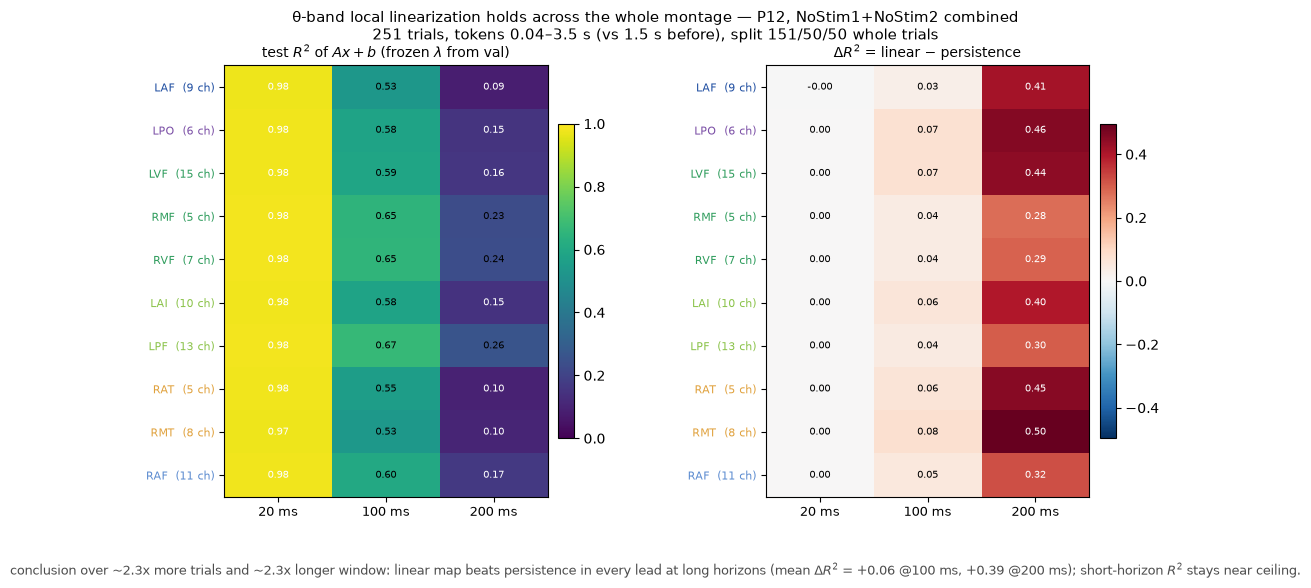

In [18]:
# --- Robustness figure: leads x horizons heatmaps ---
order = summary.sort_values(["area", "lead"]).drop_duplicates("lead")["lead"].tolist()
R2lin = summary.pivot(index="lead", columns="horizon_ms", values="R2_linear").loc[order]
R2per = summary.pivot(index="lead", columns="horizon_ms", values="R2_persistence").loc[order]
dR2 = R2lin - R2per
n_ch_of = summary.drop_duplicates("lead").set_index("lead")["n_ch"]
area_of = summary.drop_duplicates("lead").set_index("lead")["area"]

fig2, axes2 = plt.subplots(1, 2, figsize=(11.5, 5.6), gridspec_kw=dict(wspace=0.55))

def heat(ax, M, title, cmap, vmin, vmax):
    im = ax.imshow(M.to_numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(HORIZONS_EXT)), [f"{h} ms" for h in HORIZONS_EXT], fontsize=9)
    ax.set_yticks(range(len(order)), [f"{ld}  ({int(n_ch_of[ld])} ch)" for ld in order], fontsize=8)
    for lbl, ld in zip(ax.get_yticklabels(), order):
        lbl.set_color(AREA_COLORS[area_of[ld]])
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if (v - vmin) / (vmax - vmin + 1e-12) > 0.75 or (v - vmin) / (vmax - vmin + 1e-12) < 0.2 else "black")
    ax.set_title(title, fontsize=10)
    fig2.colorbar(im, ax=ax, fraction=0.045, pad=0.03)

vlo = float(min(0.0, R2lin.to_numpy().min()))
heat(axes2[0], R2lin, "test $R^2$ of $Ax+b$ (frozen $\\lambda$ from val)", "viridis", vlo, 1.0)
dmax = float(np.abs(dR2.to_numpy()).max())
heat(axes2[1], dR2, "$\\Delta R^2$ = linear $-$ persistence", "RdBu_r", -dmax, dmax)

d100 = dR2[100].mean(); d200 = dR2[200].mean()
fig2.suptitle(
    f"θ-band local linearization holds across the whole montage — P12, NoStim1+NoStim2 combined\n"
    f"{n_all} trials, tokens 0.04–{T_END_MS/1000:.1f} s (vs 1.5 s before), split {len(tr_a)}/{len(va_a)}/{len(te_a)} whole trials",
    fontsize=10.5)
fig2.text(0.5, -0.03,
          f"conclusion over ~2.3x more trials and ~2.3x longer window: linear map beats persistence in every lead at long horizons "
          f"(mean $\\Delta R^2$ = +{d100:.2f} @100 ms, +{d200:.2f} @200 ms); short-horizon $R^2$ stays near ceiling.",
          ha="center", fontsize=9, color="0.3")
fig2.tight_layout()
for ext in ("png", "pdf"):
    fig2.savefig(FIG_DIR / f"robustness_summary_P12_theta.{ext}", dpi=200, bbox_inches="tight")
print(f"saved -> {FIG_DIR / 'robustness_summary_P12_theta.png'}")
plt.show()

**Figure — Robustness of θ-band local linearization across the whole montage (P12, NoStim1 + NoStim2 combined, 251 trials, tokens 0.04–3.5 s).** Per-lead linear models (all leads with ≥5 clean channels; y-labels colored by anatomical area). **Left:** held-out test $R^2$ of $Ax+b$ per lead × horizon — near ceiling (≥0.9) at short horizons in every lead, decaying gracefully with Δ. **Right:** ΔR² = linear − persistence — positive in **every lead at every horizon**, growing to a mean of ≈ +0.06 at 100 ms and ≈ +0.39 at 200 ms. With ~2.3× more trials and a ~2.3× longer analysis window than the POC, the conclusion is unchanged and montage-wide: theta-power dynamics are well described by a local linear map, and the map (not mere signal smoothness) carries real predictive structure at long horizons.

## 6. Horizon sweep (STEP 7, Analysis 3)

Δ ∈ {10, 20, 50, 100, 200} ms × {persistence, $Ax$, $Ax+\hat{w}$} × patients → `results/horizon_metrics.csv`. No monotonicity forced.

In [24]:
td_s = sess_stim["trials"]
print(list(td_s.columns))
stim_mask = td_s["Stimulation"].to_numpy() == 1
print("stim trials:", stim_mask.sum(), "| non-stim:", (~stim_mask).sum())
# look for stim-timing-ish columns
for c in td_s.columns:
    v = td_s[c]
    if v.nunique() > 2:
        print(f"{c:>28s}: min={v.min():.3g} max={v.max():.3g} (stim-trials mean={v[stim_mask].mean():.3g}, nonstim={v[~stim_mask].mean():.3g})")

['TrialNum (FT)', 'Trial number', 'Fixation Onset NEV', 'Image Onset NEV', 'Stim on/off NEV', 'Stim onset NEV', 'Stim offset NEV', 'Response value NEV', 'Reaction onset NEV', 'Congruent Value NEV', 'Valence Value NEV', 'Reaction time NEV', 'Trial', 'Condition', 'Conflict', 'Stimulation', 'Stimuli', 'Correct', 'ISI', 'FixStimTime', 'FixStimLength', 'NumStimTime', 'NumStimLength', 'RespStimTime', 'RespStimLength', 'ResponseKey', 'ResponseAccuracy', 'NumStimOnset', 'NumStimOffset', 'RespStimOnset', 'RespStimOffset', 'FixOnset', 'NumOnset', 'ResponseOnset', 'ResponseTime', 'ResponseUncertainty']
stim trials: 114 | non-stim: 269
               TrialNum (FT): min=1 max=383 (stim-trials mean=209, nonstim=185)
                Trial number: min=1 max=383 (stim-trials mean=209, nonstim=185)
          Fixation Onset NEV: min=100 max=2.89e+03 (stim-trials mean=1.75e+03, nonstim=1.47e+03)
             Image Onset NEV: min=102 max=2.89e+03 (stim-trials mean=1.76e+03, nonstim=1.48e+03)
              

## 7. OOD: drug-state shift (STEPS 10-11, Analyses 4 + control)

Train placebo → frozen model → test held-out placebo (ID) vs scopolamine (OOD). Then the symmetric reverse (train scopolamine). Report $R^2_{ID} - R^2_{OOD}$ and residual-energy change → `results/ood_metrics.csv`.

In [ ]:
# TODO: OOD analysis (frozen model, both directions). Secondary: FR<->AR task transfer (spec §16).

## 8. Robustness & controls (STEPS 12, 14; spec §20)

Frequency bands (all 5) · temporal shuffle (should collapse) · trial shuffle (should strongly decrease) · electrode-count subsampling · patient-wise leave-one-out on the central claim.

In [ ]:
# TODO: shuffle controls + band robustness.

## 9. Cross-region "layer" mapping (STEP 13, Analysis 5)

Temporal cortex → entorhinal → hippocampus; lags δ ∈ {0, 10, 20, 50, 100} ms (selected on training data, all reported). Compare recurrent-only $R_l x^{(l+1)}_t$ vs source+recurrent $A_l x^{(l)}_t + R_l x^{(l+1)}_t$ → `results/layer_metrics.csv`.

In [ ]:
# TODO: cross-region models (only where simultaneous coverage exists; never fabricate layers).

## 10. Matrix diagnostics (spec §18)

Eigenvalue spectrum (complex plane), spectral radius, singular values, effective rank, condition number of each fitted $A$.

In [ ]:
# TODO: A-matrix diagnostics.

## 11. Patient-level statistics (STEP 15, spec §19)

One summary metric per patient per comparison → paired statistics across patients (linear vs linear+residual; ID vs OOD). Individual patient dots in all plots.

In [ ]:
# TODO: paired stats (Wilcoxon / paired t as appropriate).

## 12. Main four-panel figure (STEP 16, spec §22-24)

A: brain-as-network mapping · B: local linearization + representative real prediction (patient closest to median improvement — predefined, no cherry-picking) · C: horizon curves · D: OOD degradation. Colors: black = truth, blue = $Ax$, red = $Ax+\hat{w}$, identical across panels. Vector output.

In [ ]:
# TODO: figure assembly -> figures/main_figure.pdf/.png